## Contribuição de Preparação dos dados

Origem: `notebooks/01_preparacao_dados.ipynb`

# T326 — Ciência de Dados | Trabalho 1
## 01 — preparação dos dados: preparação e integração dos dados

**Universidade de Fortaleza — Equipe: Luma, Amanda, Peter e Luís.**

Pergunta-guia do trabalho: **“O Brasil é um país desigual?”**

Esta etapa prepara uma base municipal reproduzível do **Sudeste (ES, MG, RJ e SP)**. Seu objetivo é verificar fontes, cobertura, unidades e qualidade e calcular PIB per capita. As análises econômicas, rankings e gráficos dos colegas não são implementados aqui. A preparação sozinha não responde à pergunta-guia.

## 2. Fontes e referência temporal

Arquivos fornecidos pelo professor, obtidos pelos IDs de Google Drive:

| Fonte | ID | Nome original verificado no Drive |
|---|---|---|
| PIB municipal — SIDRA | `1GQVxYHY9ouZvh_Jkbzt3sjnWHslxGqnX` | `tabela5938_2020.csv.xz` |
| Estimativa populacional — SIDRA | `1OLg85S7vAr4MQomc_wcaQhRo6SLciSu0` | `tabela6579_2020.csv.xz` |
| DTB | `1G3Ll5LsIhsvpodjnKg6JE0KXbc_D-BSP` | `RELATORIO_DTB_BRASIL_MUNICIPIO.csv` |

PIB e população não contêm coluna de ano: **2020 vem dos nomes originais**, confirmados pelo cabeçalho HTTP `Content-Disposition` e pelos títulos do Drive. A evidência e os hashes estão em `data/raw/downloads.jsonl` e `config.json`. A DTB não informa sua edição; essa limitação será mantida no relatório.

Metadados de referência: [SIDRA 5938](https://sidra.ibge.gov.br/tabela/5938), [SIDRA 6579](https://sidra.ibge.gov.br/tabela/6579), [DTB](https://www.ibge.gov.br/geociencias/organizacao-do-territorio/divisao-regional/23701-divisao-territorial-brasileira.html), [códigos municipais](https://www.ibge.gov.br/explica/codigos-dos-municipios.php). Essas páginas contextualizam as fontes; não substituem os arquivos fornecidos.

## 3. Bibliotecas e carregamento

Execute com o Python do ambiente `.venv`. A raiz é encontrada por `config.json` e `src/sudeste`, permitindo iniciar o kernel na raiz ou na pasta de notebooks. O notebook não depende de caminhos absolutos nem de acesso à rede após o download.

In [1]:
from pathlib import Path
import json
import sys
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

# Localização portátil da raiz do projeto.
RAIZ = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'config.json').is_file() and (p / 'src/sudeste').is_dir()), None)
if RAIZ is None:
    raise FileNotFoundError('Execute este notebook dentro da pasta do projeto.')
if str(RAIZ / 'src') not in sys.path:
    sys.path.insert(0, str(RAIZ / 'src'))

from sudeste.io import carregar_fontes
from sudeste.pipeline import normalizar, integrar, validar_final, exportar
from sudeste.preparacao import filtrar_sudeste, selecionar_ano

CONFIG = json.loads((RAIZ / 'config.json').read_text(encoding='utf-8'))
# Para escolher outro ano, ele precisa existir em AMBAS as fontes.
# CONFIG['ano'] = 2020
bases, inventario = carregar_fontes(RAIZ, CONFIG)
display(pd.DataFrame({n: {k: i.get(k) for k in
    ['nome_original', 'formato', 'compactacao', 'encoding', 'registros', 'ano_metadados']}
    for n, i in inventario.items()}).T)

,nome_original,formato,compactacao,encoding,registros,ano_metadados
pib,tabela5938_2020.csv.xz,csv,xz,utf-8,5570,2020
populacao,tabela6579_2020.csv.xz,csv,xz,utf-8,5570,2020
dtb,RELATORIO_DTB_BRASIL_MUNICIPIO.csv,csv,None,utf-8,5570,None


## 4. Inspeção inicial

A leitura identifica XZ pela assinatura do arquivo, descompacta em memória e preserva os originais. Os três conteúdos reais são CSV UTF-8, separados por vírgula e com cabeçalho na primeira linha; não há abas. Inicialmente, as colunas são lidas como texto para preservar códigos geográficos e marcadores de ausência. O inventário registra também tipos inferidos, colunas, vazios e duplicatas.

In [2]:
for nome, dados in bases.items():
    display(Markdown(f'### Fonte: {nome} — {len(dados)} registros'))
    display(dados.head(3))
    display(pd.DataFrame({
        'tipo_leitura': dados.dtypes.astype(str),
        'vazios': dados.apply(lambda s: s.str.strip().eq('').sum()),
    }))
    print('Duplicatas exatas:', dados.duplicated().sum())

### Fonte: pib — 5570 registros

,Cód.,Município,PIB (Mil Reais),Impostos (Mil Reais),VA da agropecuária (Mil Reais),VA da indústria (Mil Reais),VA dos serviços (Mil Reais),VA da administração pública (Mil Reais)
0,1100015,Alta Floresta D'Oeste (RO),570272.0,35109.0,203394.0,20716.0,150192.0,160860.0
1,1100023,Ariquemes (RO),2818049.0,295656.0,199723.0,404752.0,1207405.0,710513.0
2,1100031,Cabixi (RO),167190.0,7237.0,81177.0,5438.0,28667.0,44671.0


,tipo_leitura,vazios
Cód.,string,0
Município,string,0
PIB (Mil Reais),string,0
Impostos (Mil Reais),string,0
VA da agropecuária (Mil Reais),string,0
VA da indústria (Mil Reais),string,0
VA dos serviços (Mil Reais),string,0
VA da administração pública (Mil Reais),string,0


Duplicatas exatas: 0


### Fonte: populacao — 5570 registros

...

Duplicatas exatas: 0


### Fonte: dtb — 5570 registros

,UF,Nome_UF,Região Geográfica Intermediária,Nome Região Geográfica Intermediária,Região Geográfica Imediata,Nome Região Geográfica Imediata,Mesorregião Geográfica,Nome_Mesorregião,Microrregião Geográfica,Nome_Microrregião,Município,Código Município Completo,Nome_Município
0,11,Rondônia,1102,Ji-Paraná,110005,Cacoal,02,Leste Rondoniense,006,Cacoal,00015,1100015,Alta Floresta D'Oeste
1,11,Rondônia,1102,Ji-Paraná,110005,Cacoal,02,Leste Rondoniense,006,Cacoal,00379,1100379,Alto Alegre dos Parecis
2,11,Rondônia,1101,Porto Velho,110002,Ariquemes,02,Leste Rondoniense,003,Ariquemes,00403,1100403,Alto Paraíso


,tipo_leitura,vazios
UF,string,0
Nome_UF,string,0
Região Geográfica Intermediária,string,0
Nome Região Geográfica Intermediária,string,0
Região Geográfica Imediata,string,0
Nome Região Geográfica Imediata,string,0
Mesorregião Geográfica,string,0
Nome_Mesorregião,string,0
Microrregião Geográfica,string,0
Nome_Microrregião,string,0


Duplicatas exatas: 0


## 5. Padronização e limpeza

A chave é `Cód.` nos arquivos SIDRA e `Código Município Completo` na DTB. A coluna `Município` da DTB é um código local de cinco dígitos e **não** é usada isoladamente no cruzamento. Códigos completos ficam como texto de sete dígitos; não completamos códigos truncados.

Os nomes das colunas recebem `snake_case` sem acentos. PIB, impostos e Valores Adicionados são multiplicados por **1.000**, conforme os cabeçalhos em mil reais. População é medida em pessoas. Códigos inválidos e chaves duplicadas interrompem a execução com auditoria; não há remoção arbitrária de duplicatas.

In [3]:
tratadas = normalizar(bases, CONFIG, RAIZ)
display(tratadas['pib'][['codigo_municipio', 'ano', 'pib_mil_reais', 'pib_total_reais']].head())
display(tratadas['dtb'][['codigo_municipio_local', 'codigo_municipio', 'municipio', 'codigo_uf', 'estado']].head())

,codigo_municipio,ano,pib_mil_reais,pib_total_reais
0,1100015,2020,570272.0,570272000.0
1,1100023,2020,2818049.0,2818049000.0
2,1100031,2020,167190.0,167190000.0
3,1100049,2020,2519353.0,2519353000.0
4,1100056,2020,600670.0,600670000.0


,codigo_municipio_local,codigo_municipio,municipio,codigo_uf,estado
0,00015,1100015,Alta Floresta D'Oeste,11,Rondônia
1,00379,1100379,Alto Alegre dos Parecis,11,Rondônia
2,00403,1100403,Alto Paraíso,11,Rondônia
3,00346,1100346,Alvorada D'Oeste,11,Rondônia
4,00023,1100023,Ariquemes,11,Rondônia


## 6. DTB e filtro do Sudeste

O código de UF da DTB determina o recorte: `31 → MG`, `32 → ES`, `33 → RJ`, `35 → SP`. A região é adicionada por essa correspondência documentada; regiões geográficas imediatas e intermediárias da DTB não são confundidas com as Grandes Regiões. O total municipal esperado nesta execução é obtido da própria DTB fornecida.

In [4]:
territorio = filtrar_sudeste(tratadas['dtb'])
display(territorio.groupby(['uf', 'estado']).size().rename('municipios_na_dtb').to_frame())
print('Cobertura territorial do recorte:', len(territorio))

,,municipios_na_dtb
uf,estado,
ES,Espírito Santo,78
MG,Minas Gerais,853
RJ,Rio de Janeiro,92
SP,São Paulo,645


Cobertura territorial do recorte: 1668


## 7. Compatibilidade temporal

A seleção utiliza o ano mais recente na interseção entre PIB e população. `config.json` torna essa escolha explícita e configurável. Arquivos sem coluna de ano só podem ser utilizados com ano e evidência documentados; os hashes evitam aplicar silenciosamente os metadados de 2020 a arquivos modificados.

In [5]:
ano, anos_comuns = selecionar_ano(tratadas['pib'], tratadas['populacao'], CONFIG.get('ano'))
print('Anos do PIB:', sorted(tratadas['pib']['ano'].unique()))
print('Anos da população:', sorted(tratadas['populacao']['ano'].unique()))
print('Anos comuns:', anos_comuns)
print('Ano selecionado:', ano)
print('Edição DTB:', CONFIG['fontes']['dtb']['evidencia_ano'])

Anos do PIB: [np.int64(2020)]
Anos da população: [np.int64(2020)]
Anos comuns: [2020]
Ano selecionado: 2020
Edição DTB: Edição não informada no conteúdo nem no nome original; não presumir 2020.


## 8. Cruzamentos e cálculo do PIB per capita

Os cruzamentos são validados como um para um, mantendo inicialmente todos os municípios da DTB do Sudeste. Uma auditoria nacional externa registra chaves sem correspondência em qualquer lado; auditorias regionais registram ausências de PIB e população.

\[
PIB\ per\ capita\;(R\$/pessoa)=\frac{PIB\ municipal\;(R\$)}{população\ municipal\;(pessoas)}
\]

População nula, zero, negativa, fracionária ou não finita e PIB nulo, negativo ou não finito impedem o cálculo: esses registros ficam em `registros_excluidos.csv`, sem imputação. Valores Adicionados e impostos não finitos viram nulos auditados; negativos são preservados e sinalizados, pois exigem interpretação da variável.

In [6]:
base_final, qualidade = integrar(tratadas, CONFIG, RAIZ, inventario)
# Conferência independente da fórmula, sem arredondamento prévio.
np.testing.assert_allclose(
    base_final['pib_per_capita_reais'].to_numpy(dtype=float),
    (base_final['pib_total_reais'] / base_final['populacao']).to_numpy(dtype=float),
    rtol=1e-12, atol=1e-8,
)
display(base_final[['codigo_municipio', 'municipio', 'uf', 'ano',
                    'pib_total_reais', 'populacao', 'pib_per_capita_reais']].head())

,codigo_municipio,municipio,uf,ano,pib_total_reais,populacao,pib_per_capita_reais
0,3200102,Afonso Cláudio,ES,2020,498896000.0,30455,16381.415203
1,3200136,Águia Branca,ES,2020,192510000.0,9631,19988.578548
2,3200169,Água Doce do Norte,ES,2020,165981000.0,10909,15215.051792
3,3200201,Alegre,ES,2020,504636000.0,29975,16835.229358
4,3200300,Alfredo Chaves,ES,2020,370237000.0,14636,25296.324132


## 9. Validações e relatório de qualidade

Validamos chave município/ano, região, ano, códigos, positividade da população, unidades, fórmula e reconciliação das exclusões. As contagens por UF abaixo são de cobertura, não análises econômicas. As categorias de perdas podem se sobrepor; o total de exclusões é contado uma única vez.

In [7]:
validar_final(base_final, qualidade)
display(pd.Series(qualidade['etapas'], name='registros').to_frame())
display(pd.Series(qualidade['perdas_e_recortes'], name='registros').to_frame())
display(pd.DataFrame({
    'dtb': qualidade['registros_por_uf_dtb'],
    'base_final': qualidade['registros_por_uf_final'],
}))
display(pd.Series(qualidade['ausentes_final'], name='ausentes').to_frame())
print('Duplicatas município/ano:', qualidade['duplicatas_chave_final'])
print('Divergências de nomes:', qualidade['divergencias_nomes'])

,registros
pib_bruto,5570
populacao_bruta,5570
dtb_bruta,5570
pib_ano_selecionado,5570
populacao_ano_selecionado,5570
dtb_sudeste,1668
pib_sudeste,1668
populacao_sudeste,1668
apos_cruzar_pib,1668
apos_cruzar_populacao,1668


,registros
pib_outros_anos,0
populacao_outros_anos,0
dtb_fora_sudeste,3902
pib_sem_dtb,0
pib_fora_sudeste_com_dtb,3902
populacao_sem_dtb,0
populacao_fora_sudeste_com_dtb,3902
dtb_sudeste_sem_pib,0
dtb_sudeste_sem_populacao,0
excluidos_calculo_invalido,0


,dtb,base_final
ES,78,78
MG,853,853
RJ,92,92
SP,645,645


,ausentes
codigo_municipio,0
municipio,0
codigo_uf,0
uf,0
estado,0
regiao,0
ano,0
pib_total_reais,0
populacao,0
pib_per_capita_reais,0


Duplicatas município/ano: 0
Divergências de nomes: 0


## 10. Exportação da base tratada

CSV UTF-8 e Parquet contêm o mesmo conjunto de registros; o Parquet preserva tipos. O exportador relê ambos, compara valores e tipos e gera metadados e relatório Markdown/JSON. Na leitura do CSV, informe `dtype` para os códigos.

In [8]:
caminho_csv, caminho_parquet = exportar(base_final, qualidade, RAIZ)
print('CSV:', caminho_csv.relative_to(RAIZ))
print('Parquet:', caminho_parquet.relative_to(RAIZ))
print('Releitura:', qualidade['releitura'])
print('Relatório: outputs/reports/qualidade.md')
# Exemplo de consumo para a equipe.
dados_equipe = pd.read_parquet(caminho_parquet)
assert len(dados_equipe) == len(base_final)

CSV: data/processed/sudeste_municipios.csv
Parquet: data/processed/sudeste_municipios.parquet
Releitura: {'csv': 'aprovada', 'parquet': 'aprovada'}
Relatório: outputs/reports/qualidade.md


## 11. Conclusões parciais e limitações

O texto a seguir é construído a partir dos resultados efetivamente executados. Não há conclusão sobre desigualdade econômica nesta etapa.

In [9]:
cobertura = ', '.join(f'{uf}: {q}' for uf, q in sorted(qualidade['registros_por_uf_final'].items()))
excluidos = qualidade['perdas_e_recortes']['excluidos_calculo_invalido']
ausentes = sum(qualidade['ausentes_final'].values())
display(Markdown(
    f'Foram disponibilizados **{len(base_final)} municípios** no ano **{ano}** ({cobertura}). '
    f'O recorte territorial incluiu {qualidade["etapas"]["dtb_sudeste"]} municípios na DTB; '
    f'{excluidos} registros foram excluídos por inviabilidade do cálculo. '
    f'A base final apresenta {qualidade["duplicatas_chave_final"]} duplicatas de município/ano '
    f'e {ausentes} valores ausentes no conjunto de colunas exportadas. '
    'As exportações CSV e Parquet passaram pela releitura.\n\n'
    'O ano econômico e populacional foi identificado nos nomes originais dos arquivos, '
    'não em uma coluna temporal. A edição da DTB permanece desconhecida, portanto a correspondência '
    'de códigos não comprova que limites territoriais sejam historicamente idênticos. '
    'Os valores monetários são correntes e o PIB per capita não equivale a renda pessoal.\n\n'
    'A base está preparada para as contribuições reais de estatística descritiva, análises econômicas e distribuição e síntese. '
    'A futura consolidação exige seus notebooks, execução conjunta do início ao fim e revisão técnica por preparação dos dados.'
))

Foram disponibilizados **1668 municípios** no ano **2020** (ES: 78, MG: 853, RJ: 92, SP: 645). O recorte territorial incluiu 1668 municípios na DTB; 0 registros foram excluídos por inviabilidade do cálculo. A base final apresenta 0 duplicatas de município/ano e 0 valores ausentes no conjunto de colunas exportadas. As exportações CSV e Parquet passaram pela releitura.

O ano econômico e populacional foi identificado nos nomes originais dos arquivos, não em uma coluna temporal. A edição da DTB permanece desconhecida, portanto a correspondência de códigos não comprova que limites territoriais sejam historicamente idênticos. Os valores monetários são correntes e o PIB per capita não equivale a renda pessoal.

A base está preparada para as contribuições reais de estatística descritiva, análises econômicas e distribuição e síntese. A futura consolidação exige seus notebooks, execução conjunta do início ao fim e revisão técnica por preparação dos dados.

## Contribuição de Estatística descritiva

Origem: `notebooks/contribuicoes/02_estatistica_descritiva.ipynb`

# Trabalho 1 de Ciência de Dados
## estatística descritiva: contextualização e análise descritiva

Universidade de Fortaleza - T326. Equipe: Luma, Amanda, Peter e Luís.

**Pergunta-guia: “O Brasil é um país desigual?”**

As diferenças de produção econômica entre municípios constituem uma dimensão
territorial da desigualdade. Esta seção investiga essa dimensão nos municípios
do Sudeste, sem tomar o PIB como medida suficiente de bem-estar ou da distribuição
da renda entre pessoas. O objetivo social é oferecer uma leitura acessível de dados
públicos que contribua para o debate informado sobre disparidades territoriais.
Esse objetivo não comprova que tenha ocorrido uma ação extensionista.

O objetivo analítico é descrever o PIB per capita municipal, identificar os cinco
maiores e menores valores de PIB total e por habitante e visualizar a distribuição.
Trata-se de estudo quantitativo, descritivo e transversal, com dados secundários.
Não se estimam relações causais nem se generalizam os resultados ao Brasil inteiro.

## Fontes, período e unidade de análise

A unidade de análise é **um município em 2020**. O recorte reúne Espírito Santo,
Minas Gerais, Rio de Janeiro e São Paulo, conforme a DTB fornecida à equipe.

| Fonte documentada por preparação dos dados | Arquivo original | Referência e uso |
|---|---|---|
| IBGE/SIDRA, tabela 5938 | tabela5938_2020.csv.xz | 2020; PIB municipal |
| IBGE/SIDRA, tabela 6579 | tabela6579_2020.csv.xz | 2020; estimativa de população residente |
| Divisão Territorial Brasileira/IBGE | RELATORIO_DTB_BRASIL_MUNICIPIO.csv | Edição não informada; códigos, nomes e UFs |

O ano de PIB e população foi identificado por preparação dos dados nos nomes originais, confirmados
pelo título no Drive e por Content-Disposition. Os CSVs originais não trazem coluna
de ano. A edição desconhecida da DTB impede afirmar equivalência histórica dos
limites territoriais apenas pela correspondência de códigos.

Esta seção lê `data/processed/sudeste_municipios.parquet`, preservando a base e os
notebooks originais. As unidades são reais correntes de 2020 para PIB total,
pessoas para população e reais por pessoa para PIB per capita. Não se aplicam
deflatores nem atualizações monetárias.

Documentação consultada: os dois notebooks `01_preparacao_dados`,
`data/processed/metadados.json`, `docs/dicionario_dados.md`,
`outputs/reports/qualidade.md` e `qualidade.json`. Os arquivos brutos e todas as
auditorias intermediárias não estão nesta cópia do repositório; o tratamento
anterior é descrito a partir desses registros, sem alegar nova execução dessa etapa.

## Preparação dos dados

A etapa de preparação inspecionou as fontes, leu inicialmente os campos como texto, padronizou
nomes de variáveis e preservou o código IBGE completo de sete dígitos como chave.
Converteu os campos monetários de mil reais para reais, multiplicando por 1.000,
e realizou cruzamentos um para um pelo código municipal. O recorte territorial
deriva dos códigos de UF 31, 32, 33 e 35. Os nomes municipais adotados são os da DTB.

O pipeline documentado interrompe a preparação quando encontra chaves inválidas
ou duplicadas. PIB ausente, negativo ou não finito e população ausente, não positiva,
não inteira ou não finita inviabilizam o cálculo e são objeto de exclusão auditada,
sem imputação. Impostos e valores adicionados foram preservados segundo as regras
documentadas por preparação dos dados, mas não são analisados nesta seção.

A etapa de preparação calculou **PIB per capita = PIB total em reais / população em pessoas**, com
PIB e população do mesmo ano. O relatório registra 5.570 linhas em cada fonte,
3.902 municípios fora do recorte e 1.668 no Sudeste. Não houve perdas nos cruzamentos,
exclusões por cálculo inválido, duplicatas, divergências de nomes ou valores ausentes
na base final. A seguir, A seção descritiva confere a base de consumo sem refazer a preparação.

In [10]:
from pathlib import Path
import hashlib
import json
import math
import statistics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, NullFormatter
from IPython.display import display, Markdown, HTML

# Prefixo am_ evita conflitos com outras contribuições na integração.
am_raiz = next((p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / 'data/processed/metadados.json').is_file()), None)
if am_raiz is None:
    raise FileNotFoundError('Execute dentro do projeto com a base tratada da preparação dos dados.')
am_entrada = am_raiz / 'data/processed/sudeste_municipios.parquet'
am_hash_antes = hashlib.sha256(am_entrada.read_bytes()).hexdigest()
am_dados = pd.read_parquet(am_entrada).copy(deep=True)
am_meta = json.loads((am_raiz / 'data/processed/metadados.json').read_text())
am_qualidade = json.loads((am_raiz / 'outputs/reports/qualidade.json').read_text())
am_saida = am_raiz / 'outputs/estatistica_descritiva'
am_tabelas = am_saida / 'tabelas'
am_figuras = am_raiz / 'outputs/figures'
for am_pasta in [am_saida, am_tabelas, am_figuras]:
    am_pasta.mkdir(parents=True, exist_ok=True)

def am_br(valor, casas=2):
    return f'{valor:,.{casas}f}'.replace(',', '_').replace('.', ',').replace('_', '.')

def am_mostrar(tabela, numericas=()):
    # Apenas a exibição é arredondada; CSVs mantêm a precisão numérica.
    copia = tabela.copy()
    for coluna in numericas:
        copia[coluna] = copia[coluna].map(am_br)
    copia = copia.rename(columns={'posicao': 'Pos.', 'municipio': 'Município',
        'uf': 'UF', 'valor': 'Valor', 'unidade': 'Unidade',
        'medida': 'Medida', 'indicador': 'Indicador', 'municipios': 'Municípios'})
    display(HTML(copia.to_html(index=False, escape=True, border=0)))

assert set(am_dados['uf']) == {'ES', 'MG', 'RJ', 'SP'}
assert am_dados['ano'].eq(2020).all() and am_meta['ano_selecionado'] == 2020
assert am_dados['regiao'].eq('Sudeste').all()
assert not am_dados.duplicated(['codigo_municipio', 'ano']).any()
assert am_dados['codigo_municipio'].str.fullmatch(r'\d{7}').all()
assert not am_dados[['municipio', 'uf']].isna().any().any()
am_cobertura = am_dados.groupby('uf').size().rename('municipios').reset_index()
assert am_cobertura.set_index('uf')['municipios'].to_dict() == dict(
    am_qualidade['registros_por_uf_final'])
am_cobertura.to_csv(am_tabelas / 'cobertura.csv', index=False)
am_mostrar(am_cobertura)
print('Registros na base:', len(am_dados), '| Duplicatas município/ano: 0')

UF,Municípios
ES,78
MG,853
RJ,92
SP,645


Registros na base: 1668 | Duplicatas município/ano: 0


## Validade e exclusões nesta seção

Valores ausentes, não finitos ou negativos de PIB total e per capita não entram nas
respectivas estatísticas ou rankings. Zero, se existisse, seria mantido nessas
análises. A população precisa ser inteira e positiva para o agregado regional.
Não há imputação nem exclusão automática de extremos. Registros inválidos, caso
existam, ficam identificados no CSV de auditoria. A escala logarítmica exige valores
estritamente positivos; essa restrição se aplica apenas ao histograma.

In [11]:
am_auditoria = []
am_validas = {}
am_exclusoes = []
for am_col in ['pib_total_reais', 'pib_per_capita_reais', 'populacao']:
    am_s = am_dados[am_col].astype(float)
    am_finito = pd.Series(np.isfinite(am_s), index=am_s.index)
    am_invalido_dominio = (am_s <= 0) | (am_s % 1 != 0) if am_col == 'populacao' else am_s < 0
    am_ok = am_finito & ~am_invalido_dominio
    am_validas[am_col] = am_ok
    am_auditoria.append({'variavel': am_col, 'ausentes': int(am_s.isna().sum()),
        'nao_finitos_sem_nulos': int((~am_finito & am_s.notna()).sum()),
        'dominio_invalido_finito': int((am_finito & am_invalido_dominio).sum()),
        'validos': int(am_ok.sum()), 'excluidos': int((~am_ok).sum())})
    for am_i in am_s.index[~am_ok]:
        am_exclusoes.append({'codigo_municipio': am_dados.loc[am_i, 'codigo_municipio'],
            'municipio': am_dados.loc[am_i, 'municipio'], 'uf': am_dados.loc[am_i, 'uf'],
            'variavel': am_col, 'valor': am_s.loc[am_i],
            'motivo': 'ausente' if pd.isna(am_s.loc[am_i]) else
                      ('nao finito' if not am_finito.loc[am_i] else 'dominio invalido')})
am_auditoria = pd.DataFrame(am_auditoria)
am_auditoria.to_csv(am_tabelas / 'auditoria_validade.csv', index=False)
pd.DataFrame(am_exclusoes, columns=['codigo_municipio', 'municipio', 'uf',
    'variavel', 'valor', 'motivo']).to_csv(am_tabelas / 'exclusoes.csv', index=False)
am_mostrar(am_auditoria)
am_par = am_validas['pib_total_reais'] & am_validas['populacao']
np.testing.assert_allclose(
    am_dados.loc[am_par, 'pib_per_capita_reais'].astype(float),
    (am_dados.loc[am_par, 'pib_total_reais'] / am_dados.loc[am_par, 'populacao']).astype(float),
    rtol=1e-12, atol=1e-8)
am_x = am_dados.loc[am_validas['pib_per_capita_reais'], 'pib_per_capita_reais'].astype(float)
assert len(am_x) > 0
display(Markdown(f'Conferência da base: **{len(am_x)} observações válidas** de PIB per capita. '
    f'Exclusões nesta variável: **{len(am_dados) - len(am_x)}**. '
    'A fórmula de PIB per capita confere com PIB total dividido pela população.'))

variavel,ausentes,nao_finitos_sem_nulos,dominio_invalido_finito,validos,excluidos
pib_total_reais,0,0,0,1668,0
pib_per_capita_reais,0,0,0,1668,0
populacao,0,0,0,1668,0


Conferência da base: **1668 observações válidas** de PIB per capita. Exclusões nesta variável: **0**. A fórmula de PIB per capita confere com PIB total dividido pela população.

## Estatística descritiva do PIB per capita

Cada município tem o mesmo peso. A média simples é a soma dos valores municipais
dividida pelo número de municípios válidos. A mediana divide a distribuição ordenada
ao meio. Q1 e Q3 delimitam os 50% centrais. Usam-se quantis com **interpolação linear**
do pandas, equivalente ao método linear do NumPy (posição `(n - 1) × p`).

A variância e o desvio padrão são **populacionais**, com `ddof=0` e divisor **N**,
pois descrevemos o universo municipal coberto pela base, e não uma amostra aleatória.
Variância = soma dos desvios quadráticos em relação à média / N; desvio padrão =
raiz quadrada da variância. Essa convenção não elimina as limitações das fontes.
A variância fica em (R$/pessoa)²; o desvio padrão mantém a unidade R$/pessoa.

Amplitude = máximo - mínimo. Intervalo interquartil (IIQ) = Q3 - Q1.
Coeficiente de variação (CV) = 100 × desvio padrão / média, calculado quando a média
é positiva. Ele expressa dispersão relativa, não um índice de desigualdade da renda
individual. Nenhuma medida é calculada a partir de valores previamente arredondados.

In [12]:
am_q1, am_q2, am_q3 = am_x.quantile([0.25, 0.50, 0.75], interpolation='linear')
am_media, am_dp = am_x.mean(), am_x.std(ddof=0)
am_cv = 100 * am_dp / am_media if am_media > 0 else np.nan
am_estat = pd.DataFrame([
    ('Observações válidas', len(am_x), 'municípios'),
    ('Média simples', am_media, 'R$/pessoa'),
    ('Mediana (Q2)', am_q2, 'R$/pessoa'),
    ('Mínimo', am_x.min(), 'R$/pessoa'),
    ('Máximo', am_x.max(), 'R$/pessoa'),
    ('Primeiro quartil (Q1)', am_q1, 'R$/pessoa'),
    ('Terceiro quartil (Q3)', am_q3, 'R$/pessoa'),
    ('Amplitude', am_x.max() - am_x.min(), 'R$/pessoa'),
    ('Variância populacional', am_x.var(ddof=0), '(R$/pessoa)²'),
    ('Desvio padrão populacional', am_dp, 'R$/pessoa'),
    ('Intervalo interquartil', am_q3 - am_q1, 'R$/pessoa'),
    ('Coeficiente de variação', am_cv, '%'),
], columns=['medida', 'valor', 'unidade'])
am_estat.to_csv(am_tabelas / 'estatisticas_pib_per_capita.csv', index=False)
am_mostrar(am_estat, ['valor'])
display(Markdown(
    f'A média é **R$ {am_br(am_media)} por pessoa**, enquanto a mediana é '
    f'**R$ {am_br(am_q2)}**. A média supera a mediana em '
    f'**{am_br((am_media / am_q2 - 1) * 100)}%**: valores elevados puxam a média '
    'para cima, de modo que ela não descreve sozinha o município central. '
    f'Os 50% centrais situam-se aproximadamente entre **R$ {am_br(am_q1)}** '
    f'e **R$ {am_br(am_q3)}**, com IIQ de **R$ {am_br(am_q3 - am_q1)}**.\n\n'
    f'O desvio padrão de **R$ {am_br(am_dp)}** é próximo à própria média, '
    f'e o CV é **{am_br(am_cv)}%**, indicando grande heterogeneidade municipal. '
    f'O mínimo é **R$ {am_br(am_x.min())}** e o máximo **R$ {am_br(am_x.max())}**, '
    f'uma razão de **{am_br(am_x.max() / am_x.min(), 1)} vezes**. '
    'Amplitude e variância são sensíveis a esses extremos; o IIQ complementa '
    'a leitura da dispersão ao focalizar a metade central dos municípios.'))

Medida,Valor,Unidade
Observações válidas,"1.668,00",municípios
Média simples,"30.364,89",R$/pessoa
Mediana (Q2),"22.531,00",R$/pessoa
Mínimo,"6.509,54",R$/pessoa
Máximo,"357.104,23",R$/pessoa
Primeiro quartil (Q1),"15.577,63",R$/pessoa
Terceiro quartil (Q3),"34.683,50",R$/pessoa
Amplitude,"350.594,69",R$/pessoa
Variância populacional,"952.058.409,68",(R$/pessoa)²
Desvio padrão populacional,"30.855,44",R$/pessoa


A média é **R$ 30.364,89 por pessoa**, enquanto a mediana é **R$ 22.531,00**. A média supera a mediana em **34,77%**: valores elevados puxam a média para cima, de modo que ela não descreve sozinha o município central. Os 50% centrais situam-se aproximadamente entre **R$ 15.577,63** e **R$ 34.683,50**, com IIQ de **R$ 19.105,87**.

O desvio padrão de **R$ 30.855,44** é próximo à própria média, e o CV é **101,62%**, indicando grande heterogeneidade municipal. O mínimo é **R$ 6.509,54** e o máximo **R$ 357.104,23**, uma razão de **54,9 vezes**. Amplitude e variância são sensíveis a esses extremos; o IIQ complementa a leitura da dispersão ao focalizar a metade central dos municípios.

## Média municipal e PIB per capita regional

A média simples responde qual é o valor médio **entre municípios**, dando o mesmo
peso a todos. O PIB per capita regional responde qual é a produção agregada por
habitante do recorte: **soma dos PIBs / soma das populações**, sempre sobre o mesmo
conjunto de municípios. Ele equivale à média dos PIBs per capita municipais ponderada
pela população. Não se deve somar os PIBs per capita, nem apresentar a média simples
como PIB per capita do Sudeste. O cálculo abaixo confere a cobertura comum.

In [13]:
am_agregado = am_dados.loc[am_par]
am_pib_soma = float(am_agregado['pib_total_reais'].sum())
am_pop_soma = int(am_agregado['populacao'].sum())
am_regional = am_pib_soma / am_pop_soma
am_ponderada = np.average(am_agregado['pib_per_capita_reais'].astype(float),
    weights=am_agregado['populacao'].astype(float))
np.testing.assert_allclose(am_regional, am_ponderada, rtol=1e-12)
am_comparacao = pd.DataFrame([
    ('Municípios no agregado', len(am_agregado), 'municípios'),
    ('PIB total do recorte', am_pib_soma, 'R$ correntes de 2020'),
    ('População total do recorte', am_pop_soma, 'pessoas'),
    ('Média simples municipal', am_media, 'R$/pessoa'),
    ('PIB per capita regional', am_regional, 'R$/pessoa'),
], columns=['indicador', 'valor', 'unidade'])
am_comparacao.to_csv(am_tabelas / 'media_municipal_e_regional.csv', index=False)
am_mostrar(am_comparacao, ['valor'])
display(Markdown(f'O agregado inclui **{len(am_agregado)} municípios** e '
    f'**{am_br(am_pop_soma, 0)} pessoas**. O PIB per capita regional é '
    f'**R$ {am_br(am_regional)}**, frente a **R$ {am_br(am_media)}** na média simples. '
    'A diferença decorre dos pesos populacionais: cada município contribui para '
    'o agregado de acordo com sua população. Ambos descrevem produção, não renda recebida.'))

Indicador,Valor,Unidade
Municípios no agregado,"1.668,00",municípios
PIB total do recorte,"3.952.694.732.000,00",R$ correntes de 2020
População total do recorte,"89.012.240,00",pessoas
Média simples municipal,"30.364,89",R$/pessoa
PIB per capita regional,"44.406,19",R$/pessoa


O agregado inclui **1668 municípios** e **89.012.240 pessoas**. O PIB per capita regional é **R$ 44.406,19**, frente a **R$ 30.364,89** na média simples. A diferença decorre dos pesos populacionais: cada município contribui para o agregado de acordo com sua população. Ambos descrevem produção, não renda recebida.

## Rankings municipais

Os rankings usam valores válidos da respectiva variável, antes do arredondamento.
Top 5 ordena do maior para o menor; Bottom 5, do menor para o maior. Em empate
numérico exato, o **código IBGE completo em ordem crescente** desempata. São exibidas
exatamente cinco linhas, mesmo em empate na quinta posição; o número de empatados
nesse limite é informado. A posição indica a ordem de exibição, não uma diferença
econômica entre valores empatados. Valores exibidos iguais após arredondamento
não são necessariamente empates reais. Todos os valores monetários referem-se a 2020.

In [14]:
am_rankings = {}
am_empates = []
for am_col, am_rotulo, am_unidade in [
    ('pib_total_reais', 'PIB total', 'R$ correntes de 2020'),
    ('pib_per_capita_reais', 'PIB per capita', 'R$/pessoa em 2020')]:
    for am_tipo, am_asc in [('top5', False), ('bottom5', True)]:
        am_ordem = am_dados.loc[am_validas[am_col]].sort_values(
            [am_col, 'codigo_municipio'], ascending=[am_asc, True], kind='stable')
        am_cinco = am_ordem.head(5)
        am_limite = am_cinco[am_col].iloc[-1]
        am_total_empatados = int(am_ordem[am_col].eq(am_limite).sum())
        am_fora = am_total_empatados - int(am_cinco[am_col].eq(am_limite).sum())
        am_nome = f'{am_tipo}_{am_col}'
        am_t = am_cinco[['codigo_municipio', 'municipio', 'uf', 'ano', am_col]].copy()
        am_t = am_t.rename(columns={am_col: 'valor'}).reset_index(drop=True)
        am_t.insert(0, 'posicao', range(1, len(am_t) + 1))
        am_t['unidade'] = am_unidade
        am_rankings[am_nome] = am_t
        am_t.to_csv(am_tabelas / f'{am_nome}.csv', index=False)
        display(Markdown(f'### {"Top 5" if not am_asc else "Bottom 5"}: {am_rotulo}'))
        am_mostrar(am_t[['posicao', 'municipio', 'uf', 'valor', 'unidade']], ['valor'])
        am_empates.append({'ranking': am_nome, 'municipios_no_valor_limite':
            am_total_empatados, 'empatados_fora_das_cinco_linhas': am_fora})
        print(f'Excluídos por valor inválido: {int((~am_validas[am_col]).sum())}. '
              f'Municípios com o valor da 5ª posição: {am_total_empatados}; '
              f'empatados fora da tabela: {am_fora}.')
pd.DataFrame(am_empates).to_csv(am_tabelas / 'empates_rankings.csv', index=False)
am_top_total = am_rankings['top5_pib_total_reais'].iloc[0]
am_top_pc = am_rankings['top5_pib_per_capita_reais'].iloc[0]
am_bottom_pc = am_rankings['bottom5_pib_per_capita_reais'].iloc[0]
display(Markdown(f'**{am_top_total.municipio} ({am_top_total.uf})** lidera em PIB total, '
    f'com **R$ {am_br(am_top_total.valor)}**. Em PIB per capita, o primeiro é '
    f'**{am_top_pc.municipio} ({am_top_pc.uf})**, com **R$ {am_br(am_top_pc.valor)} por pessoa**; '
    f'o menor valor é o de **{am_bottom_pc.municipio} ({am_bottom_pc.uf})**, '
    f'**R$ {am_br(am_bottom_pc.valor)} por pessoa**. A mudança de liderança mostra '
    'que volume de produção e produção por habitante descrevem aspectos distintos. '
    'Os rankings não identificam, por si sós, a renda ou o bem-estar dos moradores.'))

### Top 5: PIB total

Pos.,Município,UF,Valor,Unidade
1,São Paulo,SP,"748.759.007.000,00",R$ correntes de 2020
2,Rio de Janeiro,RJ,"331.279.902.000,00",R$ correntes de 2020
3,Belo Horizonte,MG,"97.509.893.000,00",R$ correntes de 2020
4,Osasco,SP,"76.311.814.000,00",R$ correntes de 2020
5,Guarulhos,SP,"65.849.311.000,00",R$ correntes de 2020


Excluídos por valor inválido: 0. Municípios com o valor da 5ª posição: 1; empatados fora da tabela: 0.


### Bottom 5: PIB total

Pos.,Município,UF,Valor,Unidade
1,Serra da Saudade,MG,"21.055.000,00",R$ correntes de 2020
2,Passabém,MG,"21.854.000,00",R$ correntes de 2020
3,Cedro do Abaeté,MG,"22.133.000,00",R$ correntes de 2020
4,São Sebastião do Rio Preto,MG,"23.463.000,00",R$ correntes de 2020
5,Paiva,MG,"25.856.000,00",R$ correntes de 2020


...

Excluídos por valor inválido: 0. Municípios com o valor da 5ª posição: 1; empatados fora da tabela: 0.


### Bottom 5: PIB per capita

Pos.,Município,UF,Valor,Unidade
1,Francisco Badaró,MG,"6.509,54",R$/pessoa em 2020
2,Chapada do Norte,MG,"6.802,93",R$/pessoa em 2020
3,São João das Missões,MG,"6.855,16",R$/pessoa em 2020
4,Ladainha,MG,"7.306,38",R$/pessoa em 2020
5,Cônego Marinho,MG,"7.655,74",R$/pessoa em 2020


Excluídos por valor inválido: 0. Municípios com o valor da 5ª posição: 1; empatados fora da tabela: 0.


**São Paulo (SP)** lidera em PIB total, com **R$ 748.759.007.000,00**. Em PIB per capita, o primeiro é **Louveira (SP)**, com **R$ 357.104,23 por pessoa**; o menor valor é o de **Francisco Badaró (MG)**, **R$ 6.509,54 por pessoa**. A mudança de liderança mostra que volume de produção e produção por habitante descrevem aspectos distintos. Os rankings não identificam, por si sós, a renda ou o bem-estar dos moradores.

## Histograma do PIB per capita municipal

O histograma usa **eixo horizontal logarítmico de base 10**, com classes igualmente
espaçadas no logaritmo, mas rótulos em reais por pessoa. Assim, distâncias iguais
representam razões iguais. Essa escolha permite visualizar valores menores sem
ocultar a cauda de valores elevados. A frequência vertical é a contagem de
municípios por intervalo multiplicativo, não densidade por real.

O número de classes é determinado pela regra de Freedman-Diaconis aplicada ao
log10 dos valores positivos: largura = 2 × IIQ(log10) / n^(1/3). As bordas cobrem
todo o intervalo observado; os intervalos são fechados à esquerda e abertos à direita,
exceto o último, que inclui a borda direita. Os valores originais permanecem intactos.
Zeros e negativos não podem aparecer no log: seriam contados e informados
separadamente, sem somar constantes artificiais. Não se retiram extremos válidos.

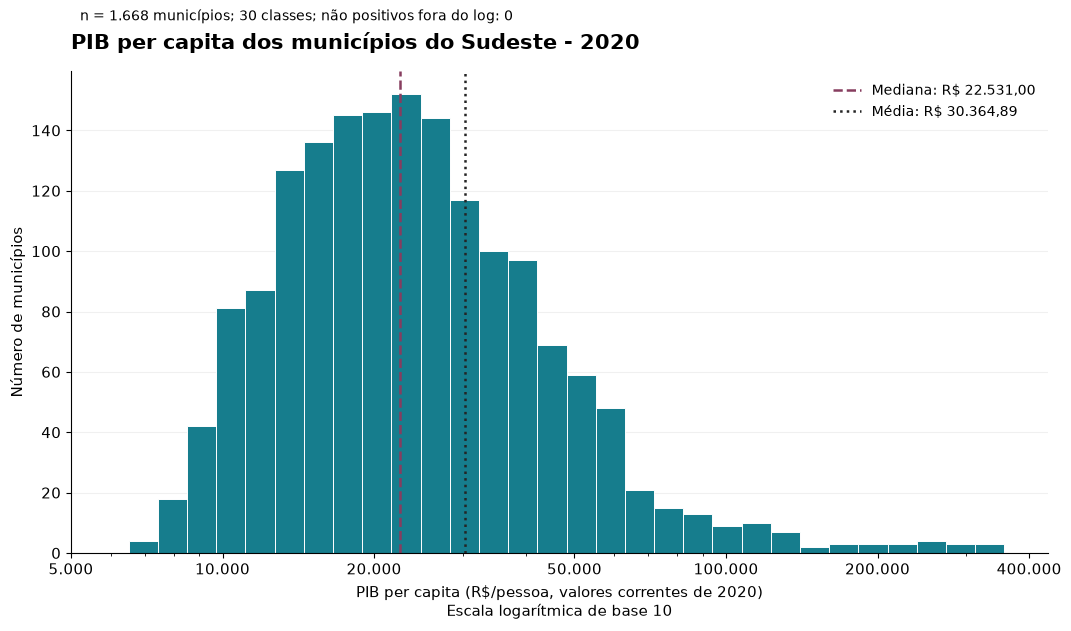

Fonte: base tratada na etapa de preparação, com PIB e população IBGE de 2020. Foram representados **1668 municípios**, com **0 valores válidos não positivos fora do log**.

A classe mais frequente contém **152 municípios**, entre **R$ 21.643,32** e **R$ 24.734,25** por pessoa. Os 50% centrais ficam entre R$ 15.577,63 e R$ 34.683,50. Apenas **42 municípios (2,52%)** superam R$ 100.000 por pessoa, formando a cauda de valores elevados. O máximo de R$ 357.104,23 foi mantido. Na escala original, a distância entre média e mediana e a extensão da cauda à direita evidenciam concentração de municípios em valores inferiores aos extremos. O log comprime as distâncias altas; a aparência do gráfico não deve ser interpretada como igualdade de distâncias monetárias nem como prova de normalidade.

In [15]:
am_positivos = am_x[am_x > 0]
am_nao_positivos = int((am_x <= 0).sum())
assert len(am_positivos) > 0
am_log = np.log10(am_positivos.to_numpy())
am_bordas_log = np.histogram_bin_edges(am_log, bins='fd')
am_bordas = np.power(10.0, am_bordas_log)
# Compensa apenas erro de ponto flutuante nas duas extremidades.
am_bordas[0] = min(am_bordas[0], float(am_positivos.min()))
am_bordas[-1] = max(am_bordas[-1], float(am_positivos.max()))
am_freq, _ = np.histogram(am_positivos, bins=am_bordas)
assert int(am_freq.sum()) == len(am_positivos)
pd.DataFrame({'limite_inferior_reais_pessoa': am_bordas[:-1],
    'limite_superior_reais_pessoa': am_bordas[1:], 'municipios': am_freq,
    'inclui_limite_superior': [False] * (len(am_freq) - 1) + [True]
}).to_csv(am_tabelas / 'classes_histograma.csv', index=False)

with plt.rc_context({'font.size': 11, 'axes.spines.top': False,
                     'axes.spines.right': False}):
    am_fig, am_ax = plt.subplots(figsize=(10.6, 6.2), layout='constrained')
    am_ax.hist(am_positivos, bins=am_bordas, color='#167D8D',
               edgecolor='white', linewidth=0.7)
    am_ax.set_xscale('log')
    am_ax.set_xticks([5000, 10000, 20000, 50000, 100000, 200000, 400000])
    am_ax.xaxis.set_major_formatter(FuncFormatter(lambda v, p: am_br(v, 0)))
    am_ax.xaxis.set_minor_formatter(NullFormatter())
    am_ax.axvline(am_q2, color='#873D5F', linestyle='--', linewidth=1.8,
                  label=f'Mediana: R$ {am_br(am_q2)}')
    am_ax.axvline(am_media, color='#242424', linestyle=':', linewidth=1.8,
                  label=f'Média: R$ {am_br(am_media)}')
    am_ax.set_title('PIB per capita dos municípios do Sudeste - 2020',
                    loc='left', fontsize=15, fontweight='bold', pad=16)
    am_ax.set_xlabel('PIB per capita (R$/pessoa, valores correntes de 2020)\nEscala logarítmica de base 10')
    am_ax.set_ylabel('Número de municípios')
    am_ax.grid(axis='y', alpha=0.18)
    am_ax.set_axisbelow(True)
    am_ax.legend(frameon=False, fontsize=10)
    am_fig.suptitle(f'n = {len(am_positivos):,}'.replace(',', '.') +
        f' municípios; {len(am_freq)} classes; não positivos fora do log: {am_nao_positivos}',
        x=0.07, ha='left', fontsize=10)
    am_fig.savefig(am_figuras / 'histograma_pib_per_capita.png', dpi=200)
    plt.show()
    plt.close(am_fig)
am_acima100 = int((am_x > 100000).sum())
am_moda_classe = int(am_freq.argmax())
display(Markdown(f'Fonte: base tratada na etapa de preparação, com PIB e população IBGE de 2020. '
    f'Foram representados **{len(am_positivos)} municípios**, com **{am_nao_positivos} '
    'valores válidos não positivos fora do log**.\n\n'
    f'A classe mais frequente contém **{int(am_freq[am_moda_classe])} municípios**, '
    f'entre **R$ {am_br(am_bordas[am_moda_classe])}** e '
    f'**R$ {am_br(am_bordas[am_moda_classe + 1])}** por pessoa. '
    f'Os 50% centrais ficam entre R$ {am_br(am_q1)} e R$ {am_br(am_q3)}. '
    f'Apenas **{am_acima100} municípios ({am_br(100 * am_acima100 / len(am_x))}%)** '
    'superam R$ 100.000 por pessoa, formando a cauda de valores elevados. '
    f'O máximo de R$ {am_br(am_x.max())} foi mantido. '
    'Na escala original, a distância entre média e mediana e a extensão da cauda '
    'à direita evidenciam concentração de municípios em valores inferiores aos extremos. '
    'O log comprime as distâncias altas; a aparência do gráfico não deve ser interpretada '
    'como igualdade de distâncias monetárias nem como prova de normalidade.'))

## Conclusões parciais e limites

As medidas descritivas, os rankings e o histograma mostram diferenças expressivas
de produção econômica por habitante entre os municípios do Sudeste em 2020.
A média acima da mediana e a presença de poucos valores muito elevados recomendam
considerar também quartis e IIQ na descrição do município típico.

**PIB total** expressa a dimensão da produção municipal. **PIB per capita** divide
essa produção pela população estimada e permite uma comparação ajustada ao tamanho
populacional. Contudo, não equivale à renda individual: não informa quanto cada
morador recebe, quem se apropria da produção nem como a renda se distribui dentro
do município. Um PIB per capita alto pode coexistir com desigualdade interna.

Os resultados oferecem evidências de desigualdade econômica **entre municípios do
recorte analisado**. Não bastam para responder, isoladamente, à pergunta sobre o
Brasil inteiro ou para concluir sobre pobreza, qualidade dos serviços ou mecanismos
causais. Isso exigiria outras regiões, indicadores e estratégias de investigação.
O estudo representa um único ano, usa população estimada e valores correntes e
preserva a limitação territorial da DTB sem edição identificada.

Esta é uma contribuição parcial de estatística descritiva. A preparação é de preparação dos dados. Análises
setoriais, correlações e comparações econômicas por UF cabem a análises econômicas; boxplot,
curtose, medidas de assimetria e conclusão geral não são executados aqui.

## Conferência independente e reprodutibilidade

A verificação abaixo compara média, mediana, variância e desvio padrão com a
biblioteca padrão `statistics`; reconstrói os quartis por interpolação linear;
confere CSV/Parquet, totais e rankings por ordenação independente; verifica
frequências do histograma e a preservação do arquivo de entrada.

Dependências de análise: pandas, numpy, pyarrow, matplotlib e IPython.
`matplotlib` é a dependência adicional ao `requirements.txt` da equipe.
Para execução automática: nbformat, nbclient, nbconvert e ipykernel.
As versões efetivamente utilizadas ficam no relatório JSON de conferência.
Os CSVs usam UTF-8, vírgula como separador e ponto decimal. Os códigos IBGE devem
ser lidos como texto. Valores não foram arredondados para a exportação.

In [16]:
am_lista = am_x.tolist()
np.testing.assert_allclose([am_media, am_q2, am_x.var(ddof=0), am_dp],
    [statistics.mean(am_lista), statistics.median(am_lista),
     statistics.pvariance(am_lista), statistics.pstdev(am_lista)], rtol=1e-12)
am_ordenados = sorted(am_lista)
def am_quantil_independente(p):
    pos = (len(am_ordenados) - 1) * p
    baixo, alto = math.floor(pos), math.ceil(pos)
    return am_ordenados[baixo] + (am_ordenados[alto] - am_ordenados[baixo]) * (pos - baixo)
np.testing.assert_allclose([am_q1, am_q2, am_q3],
    [am_quantil_independente(p) for p in [0.25, 0.5, 0.75]], rtol=1e-12)
assert am_pib_soma == math.fsum(am_agregado['pib_total_reais'].astype(float))
assert am_pop_soma == sum(int(v) for v in am_agregado['populacao'])
am_csv = pd.read_csv(am_raiz / 'data/processed/sudeste_municipios.csv',
    dtype={'codigo_municipio': 'string', 'codigo_uf': 'string'})
pd.testing.assert_frame_equal(am_dados.reset_index(drop=True), am_csv,
    check_dtype=False, rtol=1e-12, atol=1e-8)
for am_nome, am_t in am_rankings.items():
    am_col = 'pib_total_reais' if am_nome.endswith('pib_total_reais') else 'pib_per_capita_reais'
    am_sinal = -1 if am_nome.startswith('top5') else 1
    am_registros = am_dados.loc[am_validas[am_col]].to_dict('records')
    am_esperados = sorted(am_registros,
        key=lambda r: (am_sinal * r[am_col], r['codigo_municipio']))[:5]
    assert am_t['codigo_municipio'].tolist() == [r['codigo_municipio'] for r in am_esperados]
    am_lido = pd.read_csv(am_tabelas / f'{am_nome}.csv', dtype={'codigo_municipio': str})
    np.testing.assert_allclose(am_lido['valor'], am_t['valor'], rtol=1e-12)
assert int(am_freq.sum()) + am_nao_positivos == len(am_x)
assert hashlib.sha256(am_entrada.read_bytes()).hexdigest() == am_hash_antes
import importlib.metadata as am_importlib_metadata
am_relatorio = {'status': 'aprovado', 'ano': 2020, 'n': len(am_x),
    'sha256_base_parquet': am_hash_antes, 'variancia_ddof': 0,
    'quantis': 'linear', 'classes_histograma': len(am_freq),
    'nao_positivos_fora_log': am_nao_positivos,
    'verificacoes': ['statistics', 'quartis independentes', 'totais independentes',
        'CSV versus Parquet', 'rankings e releitura', 'contagem histograma', 'hash preservado'],
    'versoes': {p: am_importlib_metadata.version(p) for p in
        ['pandas', 'numpy', 'pyarrow', 'matplotlib', 'nbformat', 'nbclient', 'ipykernel']}}
(am_saida / 'conferencia.json').write_text(
    json.dumps(am_relatorio, ensure_ascii=False, indent=2), encoding='utf-8')
print('Conferências aprovadas. Base preservada. Resultados em outputs/estatistica_descritiva.')

Conferências aprovadas. Base preservada. Resultados em outputs/estatistica_descritiva.


## Referências e pendências

IBGE. PIB dos Municípios, tabela SIDRA 5938. Arquivo de 2020 fornecido à equipe,
identificado nos metadados de preparação dos dados. https://sidra.ibge.gov.br/tabela/5938

IBGE. Estimativas da população, tabela SIDRA 6579. Arquivo de 2020 fornecido à equipe,
identificado nos metadados de preparação dos dados. https://sidra.ibge.gov.br/tabela/6579

IBGE. Divisão Territorial Brasileira. Arquivo fornecido à equipe, edição não
informada. As páginas são referências institucionais documentadas por preparação dos dados;
não foram usadas para atualizar ou substituir a base.

preparação dos dados. Preparação dos dados do Trabalho 1, notebook e documentação presentes no
repositório. Registro de entrega datado de 08/09/2026.

Equipe. Divisão do Trabalho 1, documento de planejamento fornecido por estatística descritiva.
Seu escopo foi usado como contexto; não autoriza publicação, gravação ou execução
das responsabilidades dos demais integrantes.

**Pendências:** confirmar a edição da DTB se essa informação puder ser recuperada;
revisar e integrar a seção com preparação dos dados; confirmar campos e limites do Dreamshaper.
Ações extensionistas, público atendido, datas, participantes externos e impactos
dependem de evidências da equipe e não são afirmados nesta entrega.

## Contribuição de Análises econômicas

Origem: `notebooks/contribuicoes/03_analises_economicas.ipynb`

# 03. análises econômicas: setores econômicos, estados e correlações
**Análises econômicas · Ciência de Dados / UNIFOR · Sudeste, 2020**

Objetivo: descrever diferenças econômicas e populacionais entre ES, MG, RJ e SP, analisar a composição do valor adicionado (VA) e as relações entre variáveis municipais. Esta seção usa exclusivamente a base preparada pelo grupo. O recorte regional não permite generalizar os resultados para todo o Brasil.

## 1. Fontes, conceitos e decisões
- PIB e população: 2020, conforme os metadados do projeto. Valores monetários já estão em **reais correntes**, sem nova multiplicação por mil.
- Unidade de análise: município. Agregação estadual: soma dos valores municipais. PIB per capita estadual = soma do PIB / soma da população.
- Serviços: exclui administração, defesa, educação e saúde públicas e seguridade social (SIDRA 5938, variável 6575). Administração Pública corresponde a essas atividades (variável 525).
- Participação setorial = 100 × VA do setor / soma dos quatro VAs. O denominador é o **VA total**, não o PIB. Impostos líquidos de subsídios ficam fora da composição setorial.
- As participações estaduais usam somas, não a média simples dos percentuais municipais.
- Correlação de Pearson nos valores originais e em log10, complementada por Spearman entre PIB e população. Nenhuma delas demonstra causalidade.
- A edição da DTB é desconhecida. O ano de 2020 é um recorte específico, e PIB por habitante não mede renda pessoal nem distribuição de renda.

Fontes: [SIDRA 5938](https://sidra.ibge.gov.br/tabela/5938), [metadados oficiais da tabela](https://servicodados.ibge.gov.br/api/v3/agregados/5938/metadados), [SIDRA 6579](https://sidra.ibge.gov.br/tabela/6579), `data/processed/metadados.json` e `docs/dicionario_dados.md`. A resposta da API consultada em 21/09/2026 foi arquivada em `outputs/analises_economicas/fontes/` para registrar os conceitos, sem substituir os dados de 2020.

In [17]:
from pathlib import Path
import json, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from IPython.display import display, Markdown

# Encontra a raiz executando da raiz, da pasta de contribuições ou do notebook integrado.
peter_root = next((p for p in [Path.cwd(), *Path.cwd().parents]
                   if (p / 'data/processed/sudeste_municipios.parquet').exists()), None)
if peter_root is None:
    raise FileNotFoundError('Execute dentro do repositório com a base Parquet preparada por preparação dos dados.')
peter_base = peter_root / 'data/processed/sudeste_municipios.parquet'
peter_df = pd.read_parquet(peter_base).copy()
peter_out = peter_root / 'outputs/analises_economicas'
peter_fig = peter_root / 'outputs/figures'
peter_out.mkdir(parents=True, exist_ok=True)
peter_fig.mkdir(parents=True, exist_ok=True)
(peter_out / 'tabelas').mkdir(exist_ok=True)
peter_ufs = ['ES', 'MG', 'RJ', 'SP']
peter_setores = {
 'va_agropecuaria_reais': 'Agropecuária',
 'va_industria_reais': 'Indústria',
 'va_servicos_reais': 'Serviços¹',
 'va_administracao_publica_reais': 'Administração pública²'
}
peter_vas = list(peter_setores)
peter_vars = ['pib_total_reais', 'populacao', 'pib_per_capita_reais'] + peter_vas
peter_labels = ['PIB', 'População', 'PIB per capita', 'Agropecuária', 'Indústria', 'Serviços¹', 'Admin. pública²']
peter_cores = ['#287A49', '#CF8734', '#146D7A', '#873D5F']
plt.rcParams.update({'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False,
                     'figure.dpi': 110, 'axes.titleweight': 'bold'})
def peter_br(x, casas=1):
    return f'{x:,.{casas}f}'.replace(',', '_').replace('.', ',').replace('_', '.')
def peter_salvar(fig, nome):
    fig.savefig(peter_fig / f'{nome}.png', dpi=200, bbox_inches='tight')
    fig.savefig(peter_fig / f'{nome}.svg', bbox_inches='tight')
    plt.show()
    plt.close(fig)
def peter_csv(tab, nome):
    tab.to_csv(peter_out / 'tabelas' / f'{nome}.csv', encoding='utf-8', index=True)
print('SHA-256 da base:', hashlib.sha256(peter_base.read_bytes()).hexdigest())

SHA-256 da base: 26975160e61731a3ec468342e47f16cfdd42a53e2eed3c325d4ce1ffffd9b402


## 2. Conferência da base
As verificações impedem somas silenciosas com dados faltantes, duplicatas ou anos misturados. Valores negativos não são corrigidos automaticamente. Para o log, usamos somente linhas estritamente positivas e informamos as exclusões.

A identidade contábil esperada é PIB ≈ soma dos VAs + impostos líquidos de subsídios. Os seis termos foram originalmente arredondados em mil reais. Uma tolerância de R$ 3.000 por município cobre até R$ 500 de arredondamento por termo.

In [18]:
assert set(peter_df.uf) == set(peter_ufs), 'Recorte diferente do Sudeste'
assert set(peter_df.ano) == {2020}, 'Ano diferente do contrato'
assert not peter_df.duplicated(['codigo_municipio','ano']).any(), 'Chaves duplicadas'
peter_num = peter_vars + ['impostos_reais']
assert not peter_df[peter_num].isna().any().any(), 'Há valores ausentes; revisar antes de agregar'
assert np.isfinite(peter_df[peter_num].to_numpy(dtype=float)).all(), 'Há valores não finitos'
assert (peter_df.populacao > 0).all() and (peter_df.pib_total_reais > 0).all()
assert (peter_df[peter_vas] >= 0).all().all(), 'VA negativo exige revisão'
assert np.allclose(peter_df.pib_per_capita_reais,
                   peter_df.pib_total_reais / peter_df.populacao), 'PIB per capita inconsistente'
peter_df['va_total_reais'] = peter_df[peter_vas].sum(axis=1)
assert (peter_df.va_total_reais > 0).all()
peter_residuo = peter_df.pib_total_reais - peter_df.va_total_reais - peter_df.impostos_reais
assert peter_residuo.abs().max() <= 3000, 'Identidade contábil incompatível; revisar setores'
peter_cobertura = peter_df.groupby('uf').size().rename('municipios').reindex(peter_ufs)
display(peter_cobertura.to_frame())
print('Municípios:', len(peter_df))
print('Ausências nas variáveis analisadas:', int(peter_df[peter_num].isna().sum().sum()))
print('Maior resíduo absoluto (R$):', peter_residuo.abs().max())
peter_csv(peter_cobertura.to_frame(), 'cobertura')
peter_csv(peter_df[['codigo_municipio','municipio','uf']].assign(residuo_reais=peter_residuo), 'conciliacao_contabil')

,municipios
uf,
ES,78
MG,853
RJ,92
SP,645


Municípios: 1668
Ausências nas variáveis analisadas: 0
Maior resíduo absoluto (R$): 2000.0


## 3. Comparação entre estados
PIB total representa o volume produzido, população representa o número de residentes e PIB per capita expressa produção por habitante. Comparamos essas medidas separadamente para evitar confundir tamanho econômico e valor por pessoa.

,pib_total_reais,populacao,pib_per_capita_reais,participacao_pib_sudeste_pct,participacao_pop_sudeste_pct
uf,,,,,
ES,138445925000.0,4064052,34065.98,3.5,4.57
MG,682786114000.0,21292666,32066.73,17.27,23.92
RJ,753823710000.0,17366189,43407.55,19.07,19.51
SP,2377638983000.0,46289333,51364.73,60.15,52.0


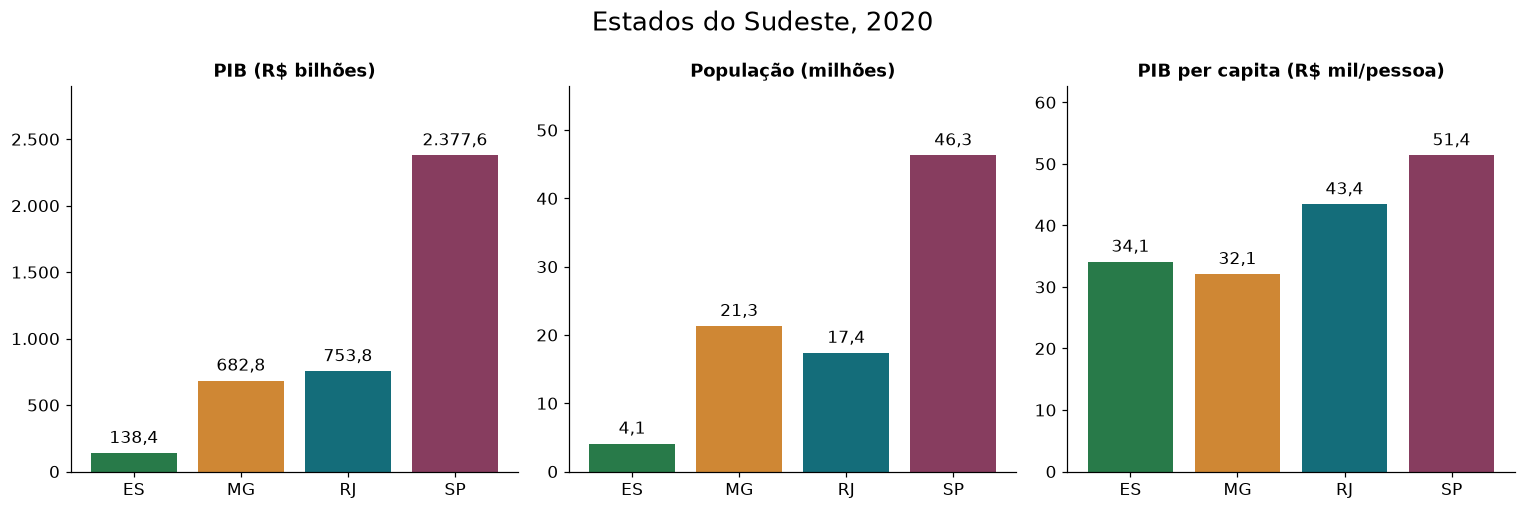

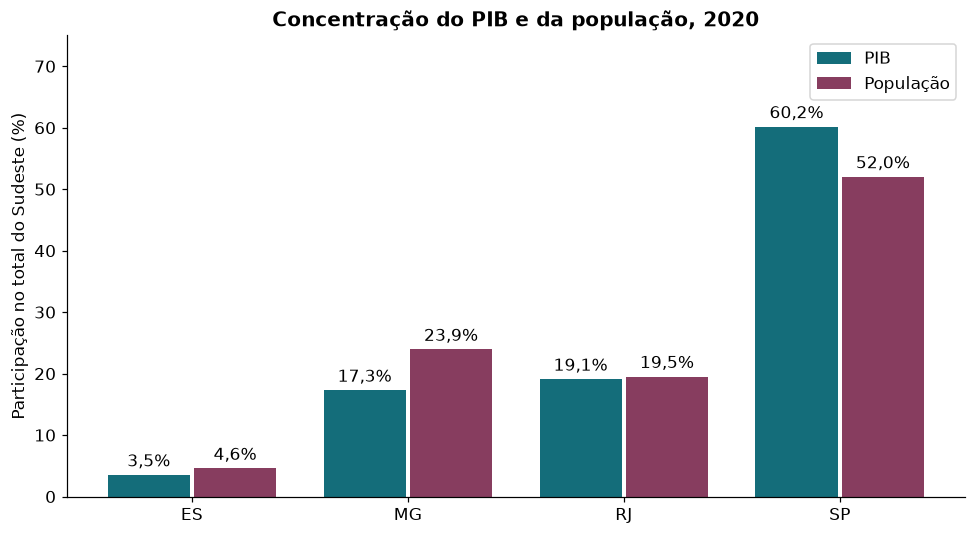

**Interpretação:** SP concentra 60,2% do PIB e 52,0% da população regional. O maior PIB per capita estadual é SP, e o menor é MG, com razão de 1,60 vez. Esses indicadores mostram disparidades territoriais de produção, sem medir diretamente a desigualdade de renda entre pessoas.

In [19]:
peter_somaveis = ['pib_total_reais','populacao','impostos_reais','va_total_reais'] + peter_vas
peter_estados = peter_df.groupby('uf')[peter_somaveis].sum().reindex(peter_ufs)
peter_estados['pib_per_capita_reais'] = peter_estados.pib_total_reais / peter_estados.populacao
peter_estados['participacao_pib_sudeste_pct'] = 100*peter_estados.pib_total_reais/peter_estados.pib_total_reais.sum()
peter_estados['participacao_pop_sudeste_pct'] = 100*peter_estados.populacao/peter_estados.populacao.sum()
peter_csv(peter_estados, 'comparacao_estados')
display(peter_estados[['pib_total_reais','populacao','pib_per_capita_reais',
                       'participacao_pib_sudeste_pct','participacao_pop_sudeste_pct']].round(2))
fig, axes = plt.subplots(1, 3, figsize=(14, 4.7))
for ax, col, escala, titulo in zip(axes,
    ['pib_total_reais','populacao','pib_per_capita_reais'], [1e9,1e6,1e3],
    ['PIB (R$ bilhões)','População (milhões)','PIB per capita (R$ mil/pessoa)']):
    valores = peter_estados[col]/escala
    bars = ax.bar(peter_ufs, valores, color=peter_cores)
    ax.bar_label(bars, labels=[peter_br(x) for x in valores], padding=4)
    ax.set_ylim(0, valores.max()*1.22)
    ax.set_title(titulo, fontsize=12)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: peter_br(x,0)))
fig.suptitle('Estados do Sudeste, 2020', fontsize=17)
fig.tight_layout()
peter_salvar(fig, 'comparacao_estados')
fig, ax = plt.subplots(figsize=(9,5))
x=np.arange(4)
for deslocamento, col, label, cor in [(-.2,'participacao_pib_sudeste_pct','PIB','#146D7A'),(.2,'participacao_pop_sudeste_pct','População','#873D5F')]:
    bars=ax.bar(x+deslocamento,peter_estados[col],width=.38,label=label,color=cor)
    ax.bar_label(bars,labels=[peter_br(v)+'%' for v in peter_estados[col]],padding=3)
ax.set_xticks(x,peter_ufs); ax.set_ylim(0,75); ax.set_ylabel('Participação no total do Sudeste (%)')
ax.set_title('Concentração do PIB e da população, 2020'); ax.legend()
fig.tight_layout(); peter_salvar(fig,'participacoes_pib_populacao')
peter_sp=peter_estados.loc['SP']
peter_razao = peter_estados.pib_per_capita_reais.max()/peter_estados.pib_per_capita_reais.min()
display(Markdown(f"""**Interpretação:** SP concentra {peter_br(peter_sp.participacao_pib_sudeste_pct)}% do PIB e {peter_br(peter_sp.participacao_pop_sudeste_pct)}% da população regional. O maior PIB per capita estadual é {peter_estados.pib_per_capita_reais.idxmax()}, e o menor é {peter_estados.pib_per_capita_reais.idxmin()}, com razão de {peter_br(peter_razao,2)} vez. Esses indicadores mostram disparidades territoriais de produção, sem medir diretamente a desigualdade de renda entre pessoas."""))

## 4. Composição econômica
O VA mede a contribuição de cada atividade à produção, descontado o consumo intermediário. A soma dos quatro setores é o denominador dos percentuais abaixo.

¹ Serviços exclui o grupo público especificado pelo IBGE. ² Administração pública inclui administração, defesa, educação e saúde públicas e seguridade social. Os rótulos abreviados nos gráficos mantêm essa definição.

,va_reais,participacao_va_sudeste_pct
Agropecuária,93293371000.0,2.76
Indústria,771869950000.0,22.8
Serviços¹,2067750923000.0,61.09
Administração pública²,452009443000.0,13.35


,Agropecuária,Indústria,Serviços¹,Administração pública²
uf,,,,
ES,4.55,27.4,51.43,16.62
MG,6.65,27.62,49.09,16.63
RJ,0.56,24.07,54.62,20.74
SP,2.2,20.69,67.32,9.79


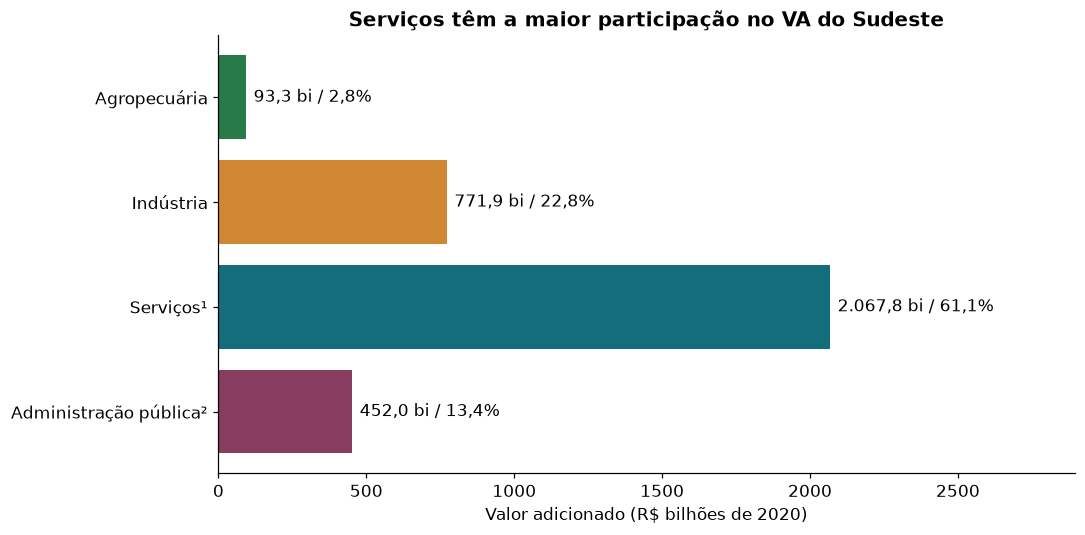

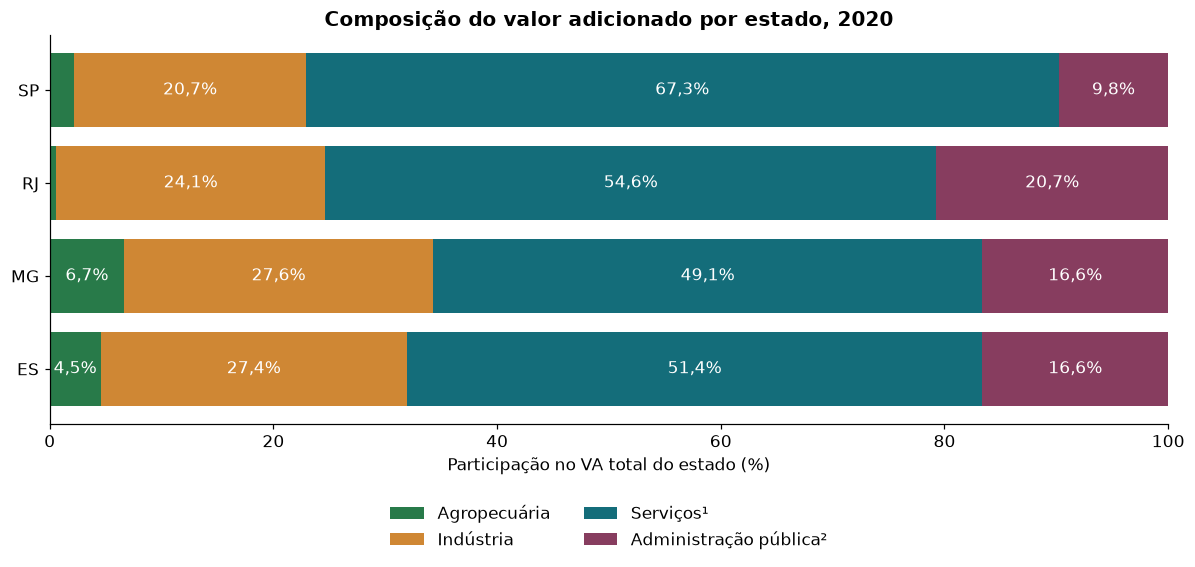

**Interpretação:** Serviços¹ responde por 61,1% do VA regional e é o maior setor em todos os quatro estados. A maior participação da Agropecuária é de MG (6,7%). A maior participação da Indústria é de MG (27,6%). Participação elevada não implica maior volume absoluto nem identifica, sozinha, a causa dessas diferenças.

In [20]:
peter_totais = peter_df[peter_vas].sum()
peter_setorial = pd.DataFrame({'va_reais':peter_totais,
    'participacao_va_sudeste_pct':100*peter_totais/peter_totais.sum()}).rename(index=peter_setores)
peter_comp = peter_estados[peter_vas].div(peter_estados.va_total_reais,axis=0)*100
assert np.allclose(peter_comp.sum(axis=1),100)
assert np.isclose(peter_setorial.participacao_va_sudeste_pct.sum(),100)
peter_csv(peter_setorial,'setores_sudeste')
peter_csv(peter_comp.rename(columns=peter_setores),'composicao_estados_pct')
display(peter_setorial.round(2)); display(peter_comp.rename(columns=peter_setores).round(2))
fig, ax=plt.subplots(figsize=(10,5))
bars=ax.barh(list(peter_setores.values()),peter_totais.values/1e9,color=peter_cores)
ax.bar_label(bars,labels=[f'{peter_br(v/1e9)} bi / {peter_br(p)}%' for v,p in zip(peter_totais,peter_setorial.participacao_va_sudeste_pct)],padding=5)
ax.set_xlim(0,peter_totais.max()/1e9*1.40);ax.invert_yaxis()
ax.set_xlabel('Valor adicionado (R$ bilhões de 2020)')
ax.set_title('Serviços têm a maior participação no VA do Sudeste')
fig.tight_layout();peter_salvar(fig,'va_setores_sudeste')
fig, ax=plt.subplots(figsize=(11,5.4))
left=np.zeros(4)
for col, cor in zip(peter_vas,peter_cores):
    valores=peter_comp[col].to_numpy(dtype=float)
    bars=ax.barh(peter_ufs,valores,left=left,label=peter_setores[col],color=cor)
    ax.bar_label(bars,labels=[peter_br(v)+'%' if v>=4 else '' for v in valores],label_type='center',color='white',fontsize=11)
    left += valores
ax.set_xlim(0,100);ax.set_xlabel('Participação no VA total do estado (%)')
ax.set_title('Composição do valor adicionado por estado, 2020')
ax.legend(loc='upper center',bbox_to_anchor=(.5,-.17),ncol=2,frameon=False)
fig.tight_layout();peter_salvar(fig,'composicao_estados')
display(Markdown(f"""**Interpretação:** Serviços¹ responde por {peter_br(peter_setorial.loc['Serviços¹','participacao_va_sudeste_pct'])}% do VA regional e é o maior setor em todos os quatro estados. A maior participação da Agropecuária é de {peter_comp.va_agropecuaria_reais.idxmax()} ({peter_br(peter_comp.va_agropecuaria_reais.max())}%). A maior participação da Indústria é de {peter_comp.va_industria_reais.idxmax()} ({peter_br(peter_comp.va_industria_reais.max())}%). Participação elevada não implica maior volume absoluto nem identifica, sozinha, a causa dessas diferenças."""))

## 5. Correlações entre municípios
A matriz usa sete variáveis econômicas e populacionais, sem códigos geográficos nem ano constante. Pearson varia de -1 a 1 e mede associação linear. Os valores originais podem ser dominados pelos municípios muito grandes. A matriz em log10 complementa a leitura ao reduzir diferenças de escala.

Há dependências de construção: os VAs compõem o PIB, e PIB per capita é PIB dividido por população. Correlações envolvendo essas variáveis não devem ser tratadas como relações independentes nem como evidência causal. Cada município tem o mesmo peso nas correlações.

N Pearson original: 1668 N log10: 1666 Excluídos do log10: 2


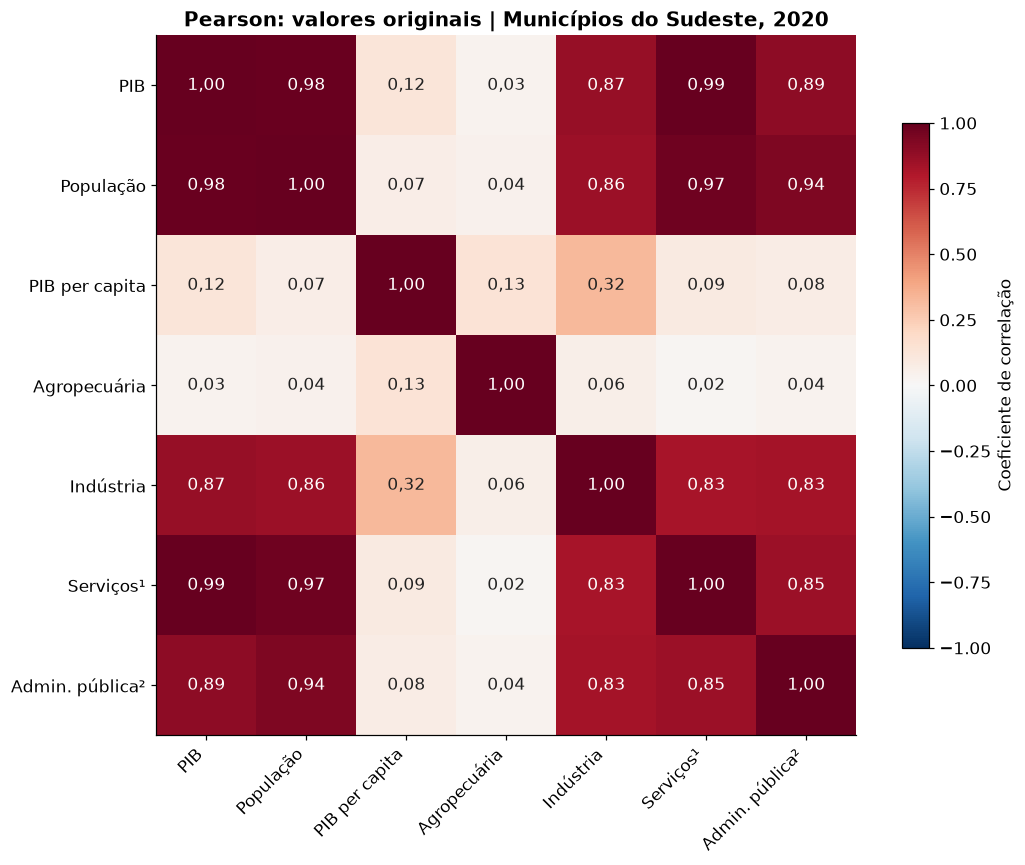

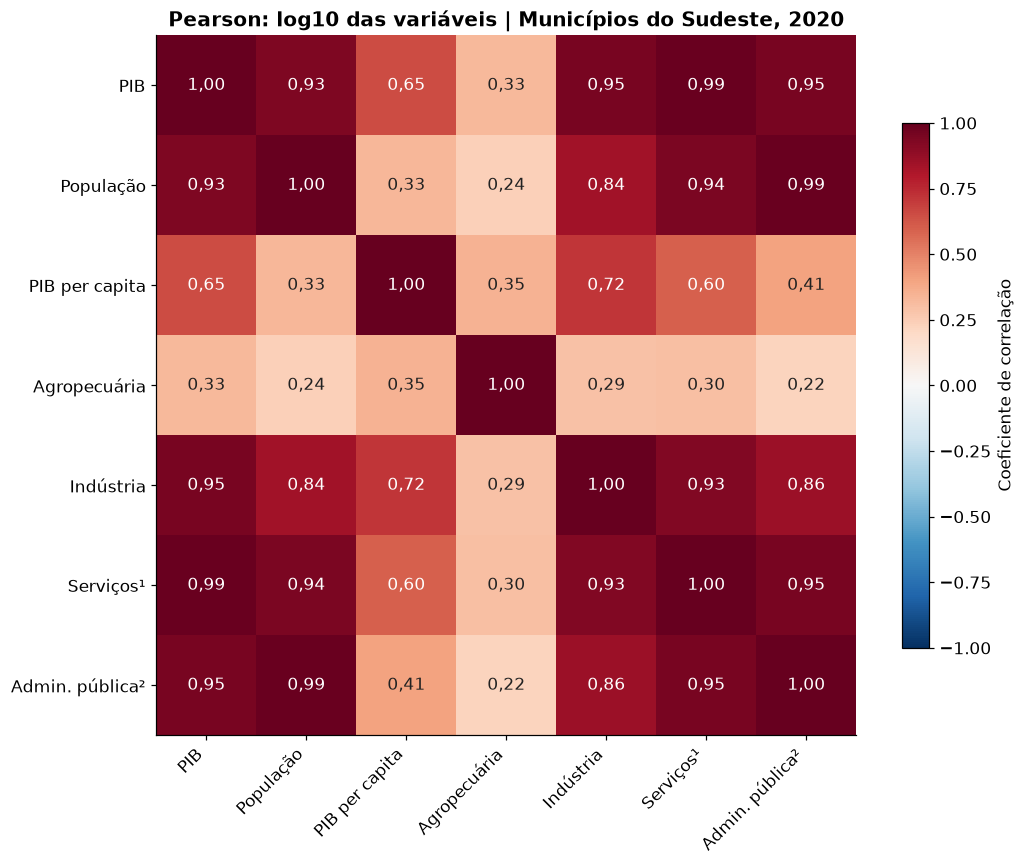

,metrica,pib_populacao,n
0,Pearson original,0.9850,1668
1,Pearson log10,0.9328,1668
2,Spearman,0.9114,1668


**Interpretação:** PIB e população apresentam associação positiva: Pearson = 0,985 nos valores originais, Pearson = 0,933 em log10 e Spearman = 0,911. A associação também aparece na ordenação dos municípios e na escala logarítmica, mas isso não elimina possíveis fatores de confusão nem prova que aumentar a população cause aumento do PIB. A análise é descritiva de 2020, sem teste causal.

In [21]:
peter_dados=peter_df[peter_vars].astype(float)
peter_corr=peter_dados.corr(method='pearson')
peter_mask_log=(peter_dados>0).all(axis=1)
peter_corr_log=np.log10(peter_dados.loc[peter_mask_log]).corr()
peter_csv(peter_corr,'correlacao_pearson_original')
peter_csv(peter_corr_log,'correlacao_pearson_log10')
print('N Pearson original:',len(peter_dados),'N log10:',int(peter_mask_log.sum()),
      'Excluídos do log10:',int((~peter_mask_log).sum()))
for matriz, titulo, nome in [(peter_corr,'Pearson: valores originais','correlacao_original'),
                             (peter_corr_log,'Pearson: log10 das variáveis','correlacao_log10')]:
    fig, ax=plt.subplots(figsize=(10,8))
    im=ax.imshow(matriz,vmin=-1,vmax=1,cmap='RdBu_r')
    ax.set_xticks(range(7),peter_labels,rotation=45,ha='right');ax.set_yticks(range(7),peter_labels)
    for i in range(7):
        for j in range(7):
            v=matriz.iloc[i,j]
            ax.text(j,i,peter_br(v,2),ha='center',va='center',color='white' if abs(v)>.6 else '#222222')
    ax.set_title(titulo+' | Municípios do Sudeste, 2020')
    fig.colorbar(im,ax=ax,shrink=.75,label='Coeficiente de correlação')
    fig.tight_layout();peter_salvar(fig,nome)
peter_r=float(peter_corr.loc['pib_total_reais','populacao'])
peter_rlog=float(np.log10(peter_dados[['pib_total_reais','populacao']]).corr().iloc[0,1])
peter_rho=float(peter_dados[['pib_total_reais','populacao']].corr(method='spearman').iloc[0,1])
peter_relacoes=pd.DataFrame({'metrica':['Pearson original','Pearson log10','Spearman'],
                           'pib_populacao':[peter_r,peter_rlog,peter_rho],'n':[len(peter_df)]*3})
peter_csv(peter_relacoes,'associacao_pib_populacao')
display(peter_relacoes.round(4))
display(Markdown(f"""**Interpretação:** PIB e população apresentam associação positiva: Pearson = {peter_br(peter_r,3)} nos valores originais, Pearson = {peter_br(peter_rlog,3)} em log10 e Spearman = {peter_br(peter_rho,3)}. A associação também aparece na ordenação dos municípios e na escala logarítmica, mas isso não elimina possíveis fatores de confusão nem prova que aumentar a população cause aumento do PIB. A análise é descritiva de 2020, sem teste causal."""))

## 6. Dispersão entre PIB e população
Cada ponto representa um município, com cor identificando o estado. Ambos os eixos usam escala logarítmica de base 10: distâncias iguais representam multiplicações iguais. A escala permite visualizar municípios pequenos e grandes no mesmo gráfico. Municípios acima de outros com população semelhante possuem maior PIB por habitante.

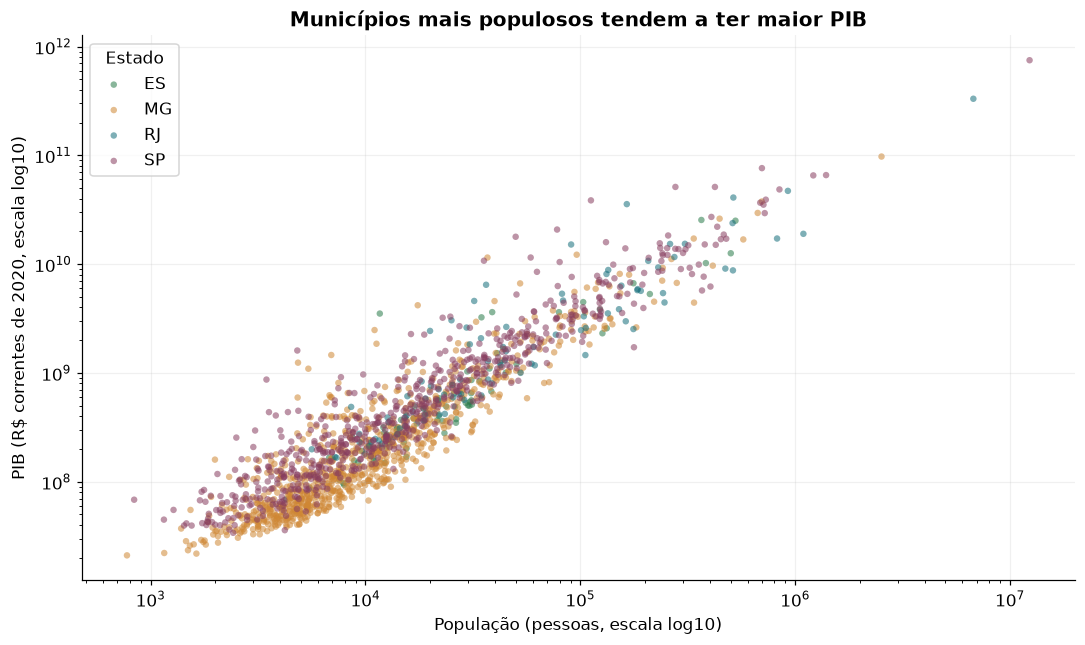

**Interpretação:** a nuvem apresenta tendência crescente, com dispersão vertical. O tamanho populacional se associa ao volume produzido, mas municípios de população semelhante podem apresentar PIBs distintos. O gráfico não identifica causas, renda disponível ou distribuição interna de renda.

In [22]:
fig, ax=plt.subplots(figsize=(10,6))
for uf, cor in zip(peter_ufs,peter_cores):
    parte=peter_df.loc[peter_df.uf==uf]
    ax.scatter(parte.populacao,parte.pib_total_reais,s=18,alpha=.55,color=cor,label=uf,edgecolors='none')
ax.set_xscale('log');ax.set_yscale('log')
ax.set_xlabel('População (pessoas, escala log10)')
ax.set_ylabel('PIB (R$ correntes de 2020, escala log10)')
ax.set_title('Municípios mais populosos tendem a ter maior PIB')
ax.legend(title='Estado');ax.grid(True,which='major',alpha=.18)
fig.tight_layout();peter_salvar(fig,'dispersao_pib_populacao')
display(Markdown('**Interpretação:** a nuvem apresenta tendência crescente, com dispersão vertical. O tamanho populacional se associa ao volume produzido, mas municípios de população semelhante podem apresentar PIBs distintos. O gráfico não identifica causas, renda disponível ou distribuição interna de renda.'))

## 7. Conclusões parciais e limites
As comparações evidenciam concentração territorial do PIB e diferenças de produção por habitante. A composição setorial varia entre estados, embora Serviços¹ tenha o maior peso em todos eles. A população se associa positivamente ao PIB municipal, sem explicar sozinha suas diferenças.

Esses resultados contribuem para a pergunta-guia com evidências de disparidades **dentro do Sudeste**. Não quantificam a desigualdade de renda entre pessoas e não substituem uma comparação entre todas as regiões brasileiras. Um único ano não permite inferir evolução, tendência histórica ou efeitos causais da pandemia.

## 8. Reprodutibilidade e integração
Executar todas as células em ordem, com as dependências gerais do repositório e `scripts/analises_economicas/requirements.txt`. Esta seção lê o Parquet sem alterá-lo. As figuras têm nomes baseados no conteúdo em `outputs/figures/`. Tabelas e roteiro ficam em `outputs/analises_economicas/`. O manifesto do grupo já aponta para `notebooks/contribuicoes/03_analises_economicas.ipynb`.

Os nomes das variáveis internas desta seção evitam conflitos na integração. A revisão visual das figuras e a execução do notebook completo devem ocorrer após a entrega de todas as seções.

In [23]:
# Exporta os mesmos resultados para os slides, sem recalcular números manualmente.
peter_resultados={
 'ano':2020,'n':len(peter_df),'sha256_base':hashlib.sha256(peter_base.read_bytes()).hexdigest(),
 'estados':peter_estados.reset_index().to_dict(orient='records'),
 'setores':peter_setorial.reset_index().to_dict(orient='records'),
 'composicao':peter_comp.reset_index().to_dict(orient='records'),
 'labels':peter_labels,'corr':peter_corr.to_numpy().tolist(),
 'r':peter_r,'r_log':peter_rlog,'rho':peter_rho,
 'n_log':int(peter_mask_log.sum()),'residuo_max_reais':float(peter_residuo.abs().max()),
 'dispersao':{uf: {'x':np.log10(peter_df.loc[peter_df.uf==uf,'populacao']).tolist(),
                   'y':np.log10(peter_df.loc[peter_df.uf==uf,'pib_total_reais']).tolist()} for uf in peter_ufs}}
(peter_out/'resultados.json').write_text(json.dumps(peter_resultados,ensure_ascii=False,indent=2),encoding='utf-8')
print('Tabelas, figuras e resultados exportados.')

Tabelas, figuras e resultados exportados.


## Contribuição de Distribuição e síntese

Origem: `notebooks/contribuicoes/04_distribuicao_sintese.ipynb`

# Distribuição, assimetria, curtose e síntese

Esta seção examina a distribuição municipal do PIB, da população e do PIB per capita
no Sudeste em 2020. O objetivo é complementar as análises anteriores com boxplots,
assimetria e curtose e, ao final, sintetizar as evidências e limitações do trabalho.

O recorte contém Espírito Santo, Minas Gerais, Rio de Janeiro e São Paulo. PIB per
capita representa produção econômica por habitante, não renda individual.

## 1. Bibliotecas, caminhos e carga da base

In [24]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis
from IPython.display import display

ds_root = next(
    (p for p in [Path.cwd(), *Path.cwd().parents]
     if (p / 'data/processed/sudeste_municipios.parquet').exists()),
    None,
)
if ds_root is None:
    raise FileNotFoundError('Base tratada não encontrada a partir do diretório atual.')

ds_df = pd.read_parquet(ds_root / 'data/processed/sudeste_municipios.parquet')
ds_fig_dir = ds_root / 'outputs/figures'
ds_out_dir = ds_root / 'outputs/distribuicao_sintese'
ds_fig_dir.mkdir(parents=True, exist_ok=True)
ds_out_dir.mkdir(parents=True, exist_ok=True)

ds_variaveis = ['pib_total_reais', 'populacao', 'pib_per_capita_reais']
ds_rotulos = ['PIB total (R$)', 'População (pessoas)', 'PIB per capita (R$)']
ds_ufs = {'ES', 'MG', 'RJ', 'SP'}

assert set(ds_df['uf'].dropna().unique()) == ds_ufs
assert ds_df[['codigo_municipio', 'ano']].duplicated().sum() == 0
assert not ds_df[ds_variaveis].isna().any().any()
assert (ds_df[ds_variaveis] > 0).all().all()
print(f'Base validada: {len(ds_df):,} municípios; ano {int(ds_df.ano.min())}.')

Base validada: 1,668 municípios; ano 2020.


## 2. Assimetria e curtose

A assimetria indica o grau de falta de simetria. Valores positivos mostram cauda à
direita. A curtose de Fisher usa zero como referência da distribuição normal;
valores positivos indicam caudas mais pesadas. As métricas são apresentadas na
escala original e após transformação $\log_{10}$.

In [25]:
ds_resultados = []
for ds_coluna, ds_rotulo in zip(ds_variaveis, ds_rotulos):
    ds_original = ds_df[ds_coluna].astype(float)
    ds_log = np.log10(ds_original)
    ds_resultados.append({
        'variavel': ds_rotulo,
        'n': len(ds_original),
        'assimetria_original': skew(ds_original, bias=False),
        'curtose_fisher_original': kurtosis(ds_original, fisher=True, bias=False),
        'assimetria_log10': skew(ds_log, bias=False),
        'curtose_fisher_log10': kurtosis(ds_log, fisher=True, bias=False),
    })

ds_metricas = pd.DataFrame(ds_resultados)
ds_metricas.to_csv(ds_out_dir / 'metricas_distribuicao.csv', index=False)
display(ds_metricas.round(3))

,variavel,n,assimetria_original,curtose_fisher_original,assimetria_log10,curtose_fisher_log10
0,PIB total (R$),1668,30.160,1026.784,0.865,0.497
1,População (pessoas),1668,27.420,859.998,0.928,1.035
2,PIB per capita (R$),1668,5.421,40.751,0.865,1.417


### Interpretação

Na escala original, as três variáveis apresentam assimetria positiva e curtose de
Fisher elevada, compatíveis com muitos municípios de valores menores e poucos
valores extremos. A transformação logarítmica reduz fortemente essas medidas, mas
não torna as distribuições simétricas: as assimetrias em log permanecem positivas,
entre aproximadamente 0,86 e 0,93. O log melhora a visualização de ordens de
grandeza diferentes, sem eliminar a heterogeneidade dos dados.

## 3. Boxplots das variáveis municipais

/var/folders/t4/v1l3095d3w3fm_txfp16v38r0000gn/T/ipykernel_9021/1706060746.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ds_ax.boxplot(ds_df[ds_coluna], vert=True, showfliers=True,
/var/folders/t4/v1l3095d3w3fm_txfp16v38r0000gn/T/ipykernel_9021/1706060746.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ds_ax.boxplot(ds_df[ds_coluna], vert=True, showfliers=True,
/var/folders/t4/v1l3095d3w3fm_txfp16v38r0000gn/T/ipykernel_9021/1706060746.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ds_ax.boxplot(ds_df[ds_coluna], vert=True, showfliers=True,


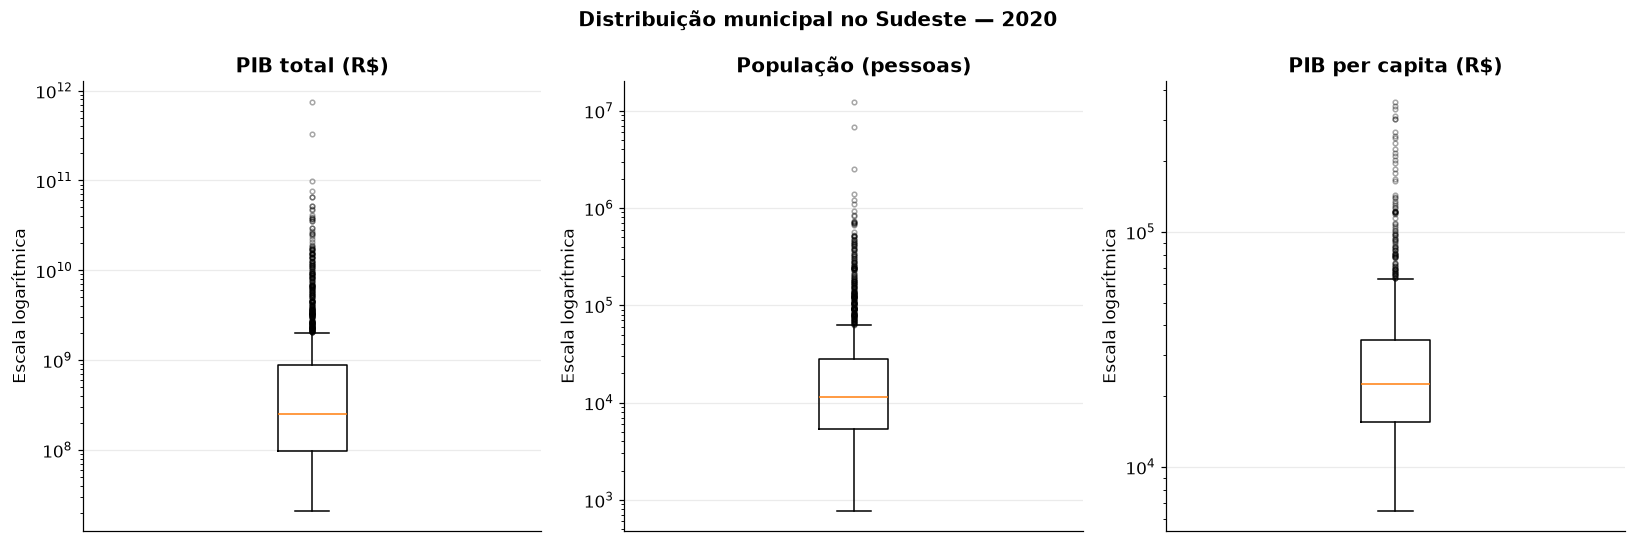

In [26]:
ds_fig, ds_axes = plt.subplots(1, 3, figsize=(15, 5))
for ds_ax, ds_coluna, ds_rotulo in zip(ds_axes, ds_variaveis, ds_rotulos):
    ds_ax.boxplot(ds_df[ds_coluna], vert=True, showfliers=True,
                  flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.35})
    ds_ax.set_yscale('log')
    ds_ax.set_title(ds_rotulo)
    ds_ax.set_ylabel('Escala logarítmica')
    ds_ax.set_xticks([])
    ds_ax.grid(axis='y', alpha=0.25)

ds_fig.suptitle('Distribuição municipal no Sudeste — 2020', fontweight='bold')
ds_fig.tight_layout()
ds_fig.savefig(ds_fig_dir / 'boxplots_distribuicao.png', dpi=180, bbox_inches='tight')
plt.show()

## 4. PIB per capita por estado

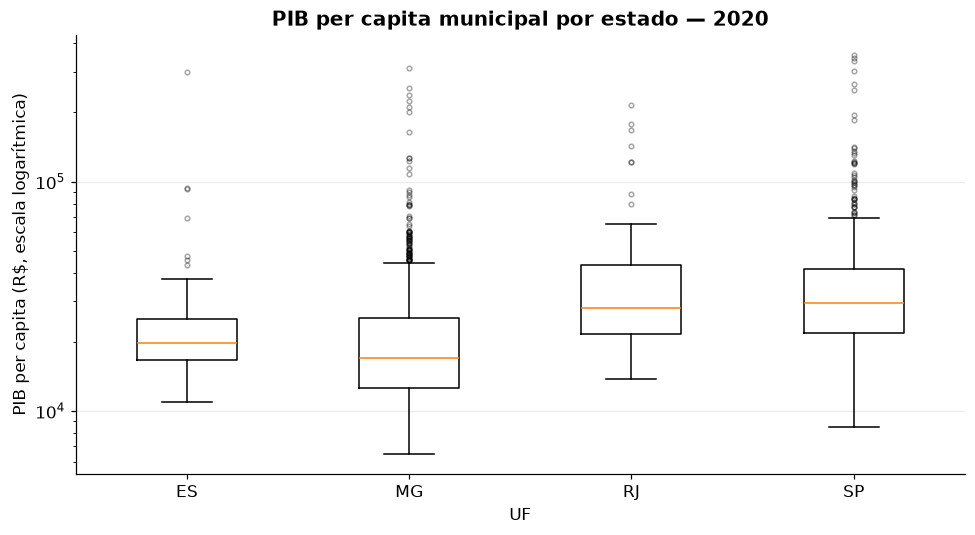

,uf,mediana_pib_per_capita_reais
3,SP,"R$ 29,433.12"
2,RJ,"R$ 28,095.57"
0,ES,"R$ 19,770.69"
1,MG,"R$ 16,968.02"


In [27]:
ds_ordem_uf = ['ES', 'MG', 'RJ', 'SP']
ds_grupos = [
    ds_df.loc[ds_df['uf'].eq(ds_uf), 'pib_per_capita_reais'].to_numpy()
    for ds_uf in ds_ordem_uf
]
ds_fig, ds_ax = plt.subplots(figsize=(9, 5))
ds_ax.boxplot(ds_grupos, tick_labels=ds_ordem_uf, showfliers=True,
              flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.35})
ds_ax.set_yscale('log')
ds_ax.set_title('PIB per capita municipal por estado — 2020', fontweight='bold')
ds_ax.set_xlabel('UF')
ds_ax.set_ylabel('PIB per capita (R$, escala logarítmica)')
ds_ax.grid(axis='y', alpha=0.25)
ds_fig.tight_layout()
ds_fig.savefig(ds_fig_dir / 'boxplot_pib_per_capita_por_uf.png', dpi=180,
               bbox_inches='tight')
plt.show()

ds_mediana_uf = (
    ds_df.groupby('uf', as_index=False)['pib_per_capita_reais']
    .median()
    .rename(columns={'pib_per_capita_reais': 'mediana_pib_per_capita_reais'})
    .sort_values('mediana_pib_per_capita_reais', ascending=False)
)
display(ds_mediana_uf.style.format({'mediana_pib_per_capita_reais': 'R$ {:,.2f}'}))

Os quatro estados apresentam valores extremos superiores e dispersão interna. São
Paulo possui a maior mediana municipal de PIB per capita no recorte, seguido por
Rio de Janeiro, Espírito Santo e Minas Gerais. Isso descreve as distribuições dos
municípios e não equivale à renda mediana de seus habitantes.

## 5. Síntese das evidências

In [28]:
ds_media_pc = ds_df['pib_per_capita_reais'].mean()
ds_mediana_pc = ds_df['pib_per_capita_reais'].median()
ds_corr_log = np.corrcoef(
    np.log10(ds_df['populacao']), np.log10(ds_df['pib_total_reais'])
)[0, 1]
ds_va = [
    'va_agropecuaria_reais', 'va_industria_reais',
    'va_servicos_reais', 'va_administracao_publica_reais',
]
ds_setor_maior = ds_df[ds_va].sum().idxmax().replace('va_', '').replace('_reais', '')

ds_sintese = pd.DataFrame({
    'indicador': [
        'Municípios analisados', 'Média municipal do PIB per capita',
        'Mediana municipal do PIB per capita',
        'Correlação de Pearson entre log10 população e log10 PIB',
        'Setor com maior VA agregado no Sudeste',
    ],
    'resultado': [
        f'{len(ds_df):,}', f'R$ {ds_media_pc:,.2f}', f'R$ {ds_mediana_pc:,.2f}',
        f'{ds_corr_log:.3f}', ds_setor_maior.title(),
    ],
})
display(ds_sintese)

,indicador,resultado
0,Municípios analisados,"1,668"
1,Média municipal do PIB per capita,"R$ 30,364.89"
2,Mediana municipal do PIB per capita,"R$ 22,531.00"
3,Correlação de Pearson entre log10 população e ...,0.933
4,Setor com maior VA agregado no Sudeste,Servicos


## 6. Conclusão geral e limitações

Os resultados sustentam que há desigualdades econômicas relevantes **entre os
municípios do Sudeste em 2020**. A média municipal do PIB per capita supera a
mediana, as distribuições possuem cauda longa à direita e os boxplots exibem muitos
valores extremos. O PIB e a população estão fortemente associados em escala
logarítmica, enquanto a composição econômica e a produção por habitante variam
entre os estados e dentro deles. Em conjunto, essas evidências mostram concentração
territorial de população e atividade econômica no recorte estudado.

Contudo, a pergunta “O Brasil é um país desigual?” é mais ampla do que esta base
permite responder. O estudo cobre somente o Sudeste e um único ano; PIB per capita
não mede renda pessoal, distribuição de renda, pobreza ou qualidade de vida. O
resultado também pode ser influenciado por municípios industriais ou petrolíferos
com população residente pequena e por deslocamentos pendulares de trabalhadores.
Uma conclusão nacional exigiria incluir as demais regiões, outros anos e indicadores
sociais como renda domiciliar, pobreza e índice de Gini.

**Fontes:** PIB dos Municípios, Estimativas da População e Divisão Territorial
Brasileira, do IBGE, conforme os arquivos originais e metadados documentados na
etapa de preparação dos dados deste projeto.